In [11]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import os
import helpers
import features
import importlib
importlib.reload(helpers)
importlib.reload(features)
from helpers import make_splits_by_is_test_or_date,CNNLSTMWithFuture, _transform_with_freeze
from features import AH_to_RH
import joblib
import json
import torch.nn as nn
from typing import Optional
from sklearn.preprocessing import StandardScaler
from dataclasses import dataclass
import torch.nn.functional as F

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FEATURES_AH = [
    "AH","AH_lag1","AH_lag2","AH_lag3",   
    "Tin","Tout","AH_out",             
    "on_runtime_1h","is_trans",              
    "hour_sin","hour_cos","month_sin","month_cos"
]

FROZEN_SUFFIXES = ("_sin", "_cos")
BINARY_COLS = {"on_runtime_1h", "is_trans"} 

def _indices_to_freeze(input_cols):
    return [
        j for j, c in enumerate(input_cols)
        if c.endswith(FROZEN_SUFFIXES) or c in BINARY_COLS
    ]

class AHSeqDataset(Dataset):
    def __init__(self, df, input_cols, window=24, target_col="AH_target", indices=None):
        if indices is None:
            indices = np.arange(len(df))
        sub = df.iloc[indices]
        X_all = sub[input_cols].values.astype(np.float32)
        y_all = sub[target_col].values.astype(np.float32)

        seqs, ys, msks = [], [], []
        for i in range(window-1, len(sub)-1):
            y = y_all[i]
            if not np.isfinite(y): 
                continue
            seqs.append(X_all[i-window+1:i+1])
            ys.append(y)
            msks.append(1.0)       # use standard (unmasked) loss
        self.X = np.asarray(seqs, np.float32)
        self.y = np.asarray(ys,   np.float32)
        self.mask = np.asarray(msks, np.float32)

    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        return (torch.tensor(self.X[i]), torch.tensor(self.y[i]), torch.tensor(self.mask[i]))


def _indices_to_freeze(input_cols):
    return [
        j for j, c in enumerate(input_cols)
        if c.endswith(FROZEN_SUFFIXES) or c in BINARY_COLS
    ]

In [12]:
@dataclass
class MaskedSeqDataset(Dataset):
    X: np.ndarray  # (N, window, D)
    y: np.ndarray  # (N,)
    mask: np.ndarray  # (N,) float in {0,1}

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return (
            torch.tensor(self.X[i], dtype=torch.float32),
            torch.tensor(self.y[i], dtype=torch.float32),
            torch.tensor(self.mask[i], dtype=torch.float32),
        )
    

def train_masked_model(
    model: nn.Module,
    train_dl: DataLoader,
    input_cols: list,
    val_dl: Optional[DataLoader] = None,
    *,
    max_epochs: int = 40,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    device: str = "cuda" if torch.cuda.is_available() else "cpu",
    verbose: int = 1,
    # ---- early stopping / sched / stability
    patience: int = 40,
    grad_clip: float = 1.0,
    # ---- loss control
    loss_type: str = "huber",   # "huber" | "mse" | "mae"
    huber_beta: float = 0.5,    # ~0.5°C for Tin; try ~0.2 for AH (g/m³)
    # ---- save knobs (defaults preserve your Tin pipeline behavior)
    save_dir: Optional[str] = None,
    df_index: Optional[int] = None,
    best_model_filename: str = "best_tinv2.pt",
    scaler_root: str = "models/scalers",
    scaler_filename: str = "scaler_tin.pkl",
    feature_json_name: Optional[str] = "tin_off_features.json",
    metric_label: str = "RMSE",     # printed label suffix
):
    # ---- fit scaler from raw (unscaled) features in the train loader ----
    frozen_idx = _indices_to_freeze(input_cols) if input_cols is not None else []
    X_all = []
    for Xb, _, _ in train_dl:
        X_all.append(Xb.numpy())
    X_all = np.concatenate(X_all, axis=0)
    Ntot, T, D = X_all.shape

    scaler = StandardScaler()
    if frozen_idx:
        non_frozen = [j for j in range(D) if j not in set(frozen_idx)]
        if non_frozen:
            X_flat = X_all.reshape(Ntot*T, D)
            scaler.fit(X_flat[:, non_frozen])
        else:
            scaler.fit(np.zeros((1, 1)))
    else:
        scaler.fit(X_all.reshape(Ntot*T, D))

    # stash frozen indices on the scaler for later use
    scaler.frozen_idx = tuple(frozen_idx)

    # ---- rebuild loaders with freeze-aware scaling ----
    def scaled_loader(dloader: DataLoader, shuffle: bool) -> DataLoader:
        Xs, ys, ms = [], [], []
        for Xb, yb, mb in dloader:
            N, T, D = Xb.shape
            X2  = Xb.numpy().reshape(N*T, D)
            X2s = _transform_with_freeze(X2, scaler).reshape(N, T, D)
            Xs.append(torch.from_numpy(X2s).float())
            ys.append(yb)
            ms.append(mb)
        Xs = torch.cat(Xs, dim=0)
        ys = torch.cat(ys, dim=0)
        ms = torch.cat(ms, dim=0)
        ds = MaskedSeqDataset(Xs.numpy(), ys.numpy(), ms.numpy())
        return DataLoader(ds, batch_size=dloader.batch_size, shuffle=shuffle)

    train_dl = scaled_loader(train_dl, shuffle=True)
    if val_dl is not None:
        val_dl = scaled_loader(val_dl, shuffle=False)

    # ---- opt / sched ----
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", factor=0.5, patience=10, cooldown=0, verbose=False
    )

    def _loss(pred, y, w):
        if loss_type == "huber":
            per = F.smooth_l1_loss(pred, y, reduction="none", beta=huber_beta)
        elif loss_type == "mse":
            per = (pred - y) ** 2
        elif loss_type == "mae":
            per = (pred - y).abs()
        else:
            raise ValueError(f"Unknown loss_type={loss_type}")
        denom = w.sum()
        return (per * w).sum() / torch.clamp(denom, min=1.0)

    best_val = float("inf")
    best_state = None
    epochs_since_improve = 0
    model.to(device)

    for epoch in range(1, max_epochs + 1):
        # ---- train ----
        model.train()
        tr_sq_sum, tr_w_sum = 0.0, 0.0
        for Xb, yb, mb in train_dl:
            Xb, yb, mb = Xb.to(device), yb.to(device), mb.to(device)
            if mb.sum().item() < 1:
                continue
            pred = model(Xb)

            loss = _loss(pred, yb, mb)
            opt.zero_grad()
            loss.backward()
            if grad_clip is not None and grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
            opt.step()

            # accumulate masked RMSE pieces for display
            tr_sq_sum += ((pred - yb) ** 2 * mb).sum().item()
            tr_w_sum  += mb.sum().item()

        tr_rmse = (tr_sq_sum / max(tr_w_sum, 1.0)) ** 0.5 if tr_w_sum > 0 else float("nan")

        # ---- validate ----
        val_rmse = float("nan")
        if val_dl is not None:
            model.eval()
            vsq_sum, vw_sum = 0.0, 0.0
            with torch.no_grad():
                for Xb, yb, mb in val_dl:
                    Xb, yb, mb = Xb.to(device), yb.to(device), mb.to(device)
                    if mb.sum().item() < 1:
                        continue
                    pred = model(Xb)
                    vsq_sum += ((pred - yb) ** 2 * mb).sum().item()
                    vw_sum  += mb.sum().item()
            val_rmse = (vsq_sum / max(vw_sum, 1.0)) ** 0.5 if vw_sum > 0 else float("nan")

            metric = val_rmse if np.isfinite(val_rmse) else float("inf")
            scheduler.step(metric)

            if metric < best_val - 1e-6:
                best_val = metric
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                epochs_since_improve = 0

                # save best
                if save_dir is not None and df_index is not None:
                    out_dir = os.path.join(save_dir, f"df_{df_index}")
                    os.makedirs(out_dir, exist_ok=True)
                    model_path = os.path.join(out_dir, best_model_filename)
                    torch.save(best_state, model_path)
                    if verbose:
                        print(f"✅ Saved best model → {model_path}")

                    scaler_dir = os.path.join(scaler_root, f"df_{df_index}")
                    os.makedirs(scaler_dir, exist_ok=True)
                    scaler_path = os.path.join(scaler_dir, scaler_filename)
                    joblib.dump(scaler, scaler_path)
                    if verbose:
                        print(f"🧪 Saved scaler → {scaler_path}")

                    if feature_json_name:
                        try:
                            with open(os.path.join(out_dir, feature_json_name), "w") as f:
                                json.dump({"input_cols": list(input_cols)}, f, indent=2)
                        except Exception:
                            pass
            else:
                epochs_since_improve += 1
                if epochs_since_improve >= patience:
                    if verbose:
                        print(f"⏹️ Early stopping at epoch {epoch} (no val improvement for {patience} epochs).")
                    break

        if verbose:
            tag = f"{metric_label}".strip()
            tmsg = f"{tag}" if tag else "train"
            vmsg = f" | val {tag}={val_rmse:.3f}" if np.isfinite(val_rmse) else ""
            print(f"Epoch {epoch:03d} | {tmsg}={tr_rmse:.3f}{vmsg} | masked steps (train)={int(tr_w_sum)}")

    if best_state is not None:
        model.load_state_dict(best_state)
    if verbose:
        print(f"🏁 Training complete. Best val {metric_label} = {best_val:.3f}")
    return model, scaler



In [7]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score
try:
    from sklearn.metrics import root_mean_squared_error
    _HAS_RMSE = True
except Exception:
    from sklearn.metrics import mean_squared_error
    _HAS_RMSE = False
try:
    from helpers import smape, setup_matplotlib, COLORS
except Exception:
    def smape(y_true, y_pred):
        y_true = np.asarray(y_true, dtype=float)
        y_pred = np.asarray(y_pred, dtype=float)
        denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
        denom[denom == 0.0] = 1.0
        return 100.0 * np.mean(np.abs(y_pred - y_true) / denom)
    def setup_matplotlib():
        plt.rcParams.update({
            "figure.dpi": 120,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.grid": True,
            "grid.alpha": 0.28,
            "legend.frameon": True,
            "legend.framealpha": 0.92,
            "font.size": 11,
        })
    COLORS = {"pred":"#ff7f0e", "eqline":"#64748b"}

def _rmse(y_true, y_pred):
    if _HAS_RMSE:
        return float(root_mean_squared_error(y_true, y_pred))
    else:
        return float(np.sqrt(mean_squared_error(y_true, y_pred)))

from matplotlib.dates import AutoDateLocator, ConciseDateFormatter
def _format_time_axis(ax):
    loc = AutoDateLocator()
    fmt = ConciseDateFormatter(loc)
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(fmt)
    ax.minorticks_on()
    ax.grid(True, which="minor", alpha=0.12)


def evaluate_ah_split(
    df: pd.DataFrame,
    indices: np.ndarray,
    model: torch.nn.Module,
    scaler,                      # the AH scaler you saved
    input_cols: list[str],       # ah_input_cols
    window: int = 24,
    device: str = "cuda" if torch.cuda.is_available() else "cpu",
    hvac_col: str = "hvac_mode",
    title_note: str = "Validation"
):
   
    sub = df.iloc[indices].copy()

    # Ensure AH columns exist (in case you evaluate outside the training prep step)
    assert "AH" in sub.columns, "AH not found. Compute it in features.py (AH from Tin/RH) before running this notebook."

    xs = []
    with torch.no_grad():
        # Recreate sequences exactly as AHSeqDataset did (but faster by using the scaler once)
        X_all = sub[input_cols].values.astype(np.float32)
        N = len(sub)
        # Construct model inputs (windowed)
        seqs = []
        target_rows = []
        for i in range(window-1, N-1):
            seq = X_all[i-window+1:i+1]                  # (T,D)
            seqs.append(seq)
            target_rows.append(i)                        # this corresponds to target at i -> time i+1

        if not seqs:
            raise ValueError("Not enough points in this split for the given window.")

        X = np.asarray(seqs, dtype=np.float32)           # (M,T,D)
        M, T, D = X.shape
        Xs = X.reshape(M*T, D)
        # freeze-aware transform
        from types import SimpleNamespace
        if not hasattr(scaler, "frozen_idx") or scaler.frozen_idx is None:
            # in case scaler saved without this attribute
            frozen = [j for j,c in enumerate(input_cols) if c.endswith(("_sin","_cos"))]
            scaler.frozen_idx = tuple(frozen)
        # scale non-frozen
        frozen = set(scaler.frozen_idx)
        non_frozen = [j for j in range(D) if j not in frozen]
        Xs_out = Xs.copy()
        if non_frozen:
            Xs_out[:, non_frozen] = scaler.transform(Xs[:, non_frozen])
        X_scaled = Xs_out.reshape(M, T, D)

        # predict
        x_t = torch.tensor(X_scaled, dtype=torch.float32, device=device)
        model = model.to(device).eval()
        AH_pred = model(x_t).detach().cpu().numpy().astype(float).ravel()

    # Gather truths & context aligned to t+1
    times = []
    AH_true = []
    RH_true = []
    RH_pred = []
    Tin_true = []
    Tout_true = []
    hvac_list = []
    hour_list = []
    month_list = []

    for j, i in enumerate(target_rows):
        t1 = sub.index[i+1]
        times.append(t1)
        AH_true.append(float(sub["AH"].iloc[i+1]))
        Tin_true.append(float(sub["Tin"].iloc[i+1]) if "Tin" in sub.columns else np.nan)
        Tout_true.append(float(sub["Tout"].iloc[i+1]) if "Tout" in sub.columns else np.nan)
        hvac_list.append(int(sub[hvac_col].iloc[i+1]) if hvac_col in sub.columns else 0)
        hour_list.append(int(pd.Timestamp(t1).hour))
        month_list.append(int(pd.Timestamp(t1).month))
        # RH (true & pred) at t+1 using true Tin_{t+1} for conversion
        RH_true.append(float(sub["RH"].iloc[i+1]) if "RH" in sub.columns else np.nan)

    AH_true = np.array(AH_true)
    Tin_arr = np.array(Tin_true)
    RH_true = np.array(RH_true)

    RH_pred = AH_to_RH(Tin_arr, AH_pred)

    # Metrics
    def _mk(y, yhat):
        return dict(
            rmse=_rmse(y, yhat),
            mae=float(mean_absolute_error(y, yhat)),
            r2=float(r2_score(y, yhat)),
            smape=float(smape(y, yhat)),
        )
    m_ah = _mk(AH_true, AH_pred)
    mask = np.isfinite(RH_true)
    m_rh = _mk(RH_true[mask], np.asarray(RH_pred)[mask]) if mask.any() else {k: np.nan for k in ("rmse","mae","r2","smape")}

    metrics = {f"AH_{k}": v for k,v in m_ah.items()} | {f"RH_{k}": v for k,v in m_rh.items()}

    dfp = pd.DataFrame({
        "AH_true": AH_true,
        "AH_pred": AH_pred,
        "RH_true": RH_true,
        "RH_pred": RH_pred,
        "Tin_true": Tin_arr,
        "Tout": np.array(Tout_true),
        hvac_col: np.array(hvac_list, dtype=int),
        "hour": np.array(hour_list, dtype=int),
        "month": np.array(month_list, dtype=int),
    }, index=pd.to_datetime(times)).sort_index()

    print(f"\n==== {title_note} — AH (g/m³) ====")
    print(f"RMSE={metrics['AH_rmse']:.3f}  MAE={metrics['AH_mae']:.3f}  R²={metrics['AH_r2']:.3f}  sMAPE={metrics['AH_smape']:.2f}%")
    print(f"==== {title_note} — RH (%) ====")
    print(f"RMSE={metrics['RH_rmse']:.3f}  MAE={metrics['RH_mae']:.3f}  R²={metrics['RH_r2']:.3f}  sMAPE={metrics['RH_smape']:.2f}%")

    return metrics, dfp

def plot_ah_results(
    dfp: pd.DataFrame,
    start=None, end=None,
    title_prefix="AH→RH one-step evaluation",
    hvac_col: str = "hvac_mode"
):
    """
    dfp is the output DataFrame from evaluate_ah_split.
    """
    setup_matplotlib()
    dd = dfp.loc[start:end] if (start is not None or end is not None) else dfp

    # compute metrics for titles
    def _mk(y, yhat):
        return _rmse(y, yhat), mean_absolute_error(y, yhat), r2_score(y, yhat), smape(y, yhat)
    rmse_rh, mae_rh, r2_rh, smp_rh = _mk(dd["RH_true"], dd["RH_pred"])
    rmse_ah, mae_ah, r2_ah, smp_ah = _mk(dd["AH_true"], dd["AH_pred"])

    # ===== Time series (RH then AH)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7.0), sharex=True)

    ax1.plot(dd.index, dd["RH_true"], lw=2.2, label="RH True")
    ax1.plot(dd.index, dd["RH_pred"], lw=2.2, ls="--", label="RH Pred")
    ax1.set_ylabel("RH [%]")
    ax1.set_title(f"RH — RMSE={rmse_rh:.3f} | MAE={mae_rh:.3f} | R²={r2_rh:.3f} | sMAPE={smp_rh:.2f}%")
    ax1.legend(loc="upper left", framealpha=0.9)

    ax2.plot(dd.index, dd["AH_true"], lw=2.2, label="AH True")
    ax2.plot(dd.index, dd["AH_pred"], lw=2.2, ls="--", label="AH Pred")
    ax2.set_ylabel("AH [g/m³]")
    ax2.set_title(f"AH — RMSE={rmse_ah:.3f} | MAE={mae_ah:.3f} | R²={r2_ah:.3f} | sMAPE={smp_ah:.2f}%")
    ax2.legend(loc="upper left", framealpha=0.9)

    _format_time_axis(ax2)
    fig.suptitle(title_prefix, y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

    # ===== Parity plots
    fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(12.8, 5.4))

    # RH
    ax3.scatter(dd["RH_true"], dd["RH_pred"], s=14, alpha=0.7, edgecolors="none", color=COLORS.get("pred", "#ff7f0e"))
    mn = float(np.nanmin([dd["RH_true"].min(), dd["RH_pred"].min()])); mx = float(np.nanmax([dd["RH_true"].max(), dd["RH_pred"].max()]))
    ax3.plot([mn, mx], [mn, mx], lw=2.0, color=COLORS.get("eqline", "#64748b"))
    ax3.set_aspect("equal", adjustable="box")
    ax3.set_xlabel("RH True [%]"); ax3.set_ylabel("RH Pred [%]")
    ax3.set_title("Parity — RH"); ax3.grid(True, alpha=0.25); ax3.minorticks_on()

    # AH
    ax4.scatter(dd["AH_true"], dd["AH_pred"], s=14, alpha=0.7, edgecolors="none", color=COLORS.get("pred", "#ff7f0e"))
    mn = float(np.nanmin([dd["AH_true"].min(), dd["AH_pred"].min()])); mx = float(np.nanmax([dd["AH_true"].max(), dd["AH_pred"].max()]))
    ax4.plot([mn, mx], [mn, mx], lw=2.0, color=COLORS.get("eqline", "#64748b"))
    ax4.set_aspect("equal", adjustable="box")
    ax4.set_xlabel("AH True [g/m³]"); ax4.set_ylabel("AH Pred [g/m³]")
    ax4.set_title("Parity — AH"); ax4.grid(True, alpha=0.25); ax4.minorticks_on()

    plt.tight_layout()
    plt.show()

def _pair_metrics(y, yhat):
    y = np.asarray(y); yhat = np.asarray(yhat)
    return dict(MAE=float(np.mean(np.abs(yhat-y))), RMSE=_rmse(y,yhat))

def summarize_rh_split(dfp: pd.DataFrame, hvac_col="hvac_mode"):
    out = {}

    # by HVAC
    if hvac_col in dfp.columns:
        rows = []
        for m in sorted(dfp[hvac_col].dropna().unique()):
            sub = dfp[dfp[hvac_col] == m]
            mrh = _pair_metrics(sub["RH_true"], sub["RH_pred"])
            mah = _pair_metrics(sub["AH_true"], sub["AH_pred"])
            rows.append([int(m), mrh["MAE"], mrh["RMSE"], mah["MAE"], mah["RMSE"], len(sub)])
        out["by_mode"] = pd.DataFrame(rows, columns=["mode","RH_MAE","RH_RMSE","AH_MAE","AH_RMSE","N"])

    # by hour
    rows = []
    for h in range(24):
        sub = dfp[dfp.index.hour == h]
        if len(sub) < 4: continue
        mrh = _pair_metrics(sub["RH_true"], sub["RH_pred"])
        mah = _pair_metrics(sub["AH_true"], sub["AH_pred"])
        rows.append([h, mrh["MAE"], mrh["RMSE"], mah["MAE"], mah["RMSE"], len(sub)])
    out["by_hour"] = pd.DataFrame(rows, columns=["hour","RH_MAE","RH_RMSE","AH_MAE","AH_RMSE","N"])

    # by Tout quantiles
    if "Tout" in dfp.columns:
        rows = []
        bins = pd.qcut(dfp["Tout"], q=6, duplicates="drop")
        for b, sub in dfp.groupby(bins):
            mrh = _pair_metrics(sub["RH_true"], sub["RH_pred"])
            mah = _pair_metrics(sub["AH_true"], sub["AH_pred"])
            rows.append([str(b), mrh["MAE"], mrh["RMSE"], mah["MAE"], mah["RMSE"], len(sub)])
        out["by_tout"] = pd.DataFrame(rows, columns=["Tout_bin","RH_MAE","RH_RMSE","AH_MAE","AH_RMSE","N"])

    # by SW quantiles if present
    sw_col = next((c for c in ["SW_down","SW1h","SW3h"] if c in dfp.columns), None)
    if sw_col and sw_col in dfp.columns:
        rows = []
        bins = pd.qcut(dfp[sw_col], q=6, duplicates="drop")
        for b, sub in dfp.groupby(bins):
            mrh = _pair_metrics(sub["RH_true"], sub["RH_pred"])
            mah = _pair_metrics(sub["AH_true"], sub["AH_pred"])
            rows.append([str(b), mrh["MAE"], mrh["RMSE"], mah["MAE"], mah["RMSE"], len(sub)])
        out["by_sw"] = pd.DataFrame(rows, columns=["SW_bin","RH_MAE","RH_RMSE","AH_MAE","AH_RMSE","N"])

    return out

In [26]:
def run_ah_for_folder(folder_path: str, hvac_col="hvac_mode", save_root="models", win_ah=24):
    dfs = []
    for f in os.listdir(folder_path):
        if f.endswith("with_comfort.csv"):
            df = pd.read_csv(os.path.join(folder_path, f))
            df["timestamp"] = pd.to_datetime(df["timestamps"])
            df = df.drop(columns=["timestamps"]).set_index("timestamp").sort_index()
            dfs.append(df)

    device = DEVICE

    for idx, df in enumerate(dfs):
        # if you already add meteo earlier, you can skip; otherwise:
        required = [
            "AH","AH_lag1","AH_lag2","AH_lag3",
            "Tin","Tout","AH_out",
            hvac_col,"on_runtime_1h","is_trans",
            "hour_sin","hour_cos","month_sin","month_cos"
        ]
        df = df.loc[:df["hvac_mode"].last_valid_index()]
        df["hvac_mode"] = df["hvac_mode"].fillna(0).astype(int)
        df["on_runtime_1h"] = df["on_runtime_1h"].fillna(0).astype(int)
        df["is_trans"] = df["is_trans"].fillna(0).astype(int)

        # For the rest of the columns, fill NaN with 0
        df = df.fillna(0)

        missing = [c for c in required if c not in df.columns]
        assert not missing, f"[df_{idx}] Missing features from features.py: {missing}"
        g = df.copy()
        ah_input_cols = required
        train_idx, val_idx, test_idx = make_splits_by_is_test_or_date(g)

        train_ds = AHSeqDataset(g, ah_input_cols, window=win_ah, indices=train_idx)
        val_ds   = AHSeqDataset(g, ah_input_cols, window=win_ah, indices=val_idx)
        ah_train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,  drop_last=False)
        ah_val_loader   = DataLoader(val_ds,   batch_size=512, shuffle=False, drop_last=False)

        # model
        ah_model = CNNLSTMWithFuture(
            input_size=len(ah_input_cols),
            hidden_size=128, num_layers=2,
            cnn_out_channels=32, kernel_size=3
        ).to(device)
        scaler_root = os.path.join(save_root, "scalers")
        # reuse your scaler/early-stop trainer (it preserves sin/cos via frozen_idx)
        ah_model, ah_scaler = train_masked_model(
            model=ah_model,
            train_dl=ah_train_loader,
            input_cols=ah_input_cols,
            val_dl=ah_val_loader,
            max_epochs=200,
            lr=1e-3,
            device=device,
            # AH-specific tweaks:
            loss_type="huber",
            huber_beta=0.2,                      
            metric_label="RMSE (AH)",
            # save names for AH
            save_dir=save_root,
            df_index=idx,
            best_model_filename="best_ah.pt",
            scaler_root=scaler_root,
            scaler_filename="scaler_ah.pkl",
            feature_json_name="ah_features.json",
        )
        test_metrics, test_dfp = evaluate_ah_split(
            df=g, indices=test_idx,
            model=ah_model, scaler=ah_scaler,
            input_cols=ah_input_cols, window=win_ah,
            device=device, hvac_col=hvac_col, title_note="Test"
        )
        plot_ah_results(test_dfp, title_prefix=f"[df_{idx}] AH→RH — Test")
        test_summ = summarize_rh_split(test_dfp, hvac_col=hvac_col)
        print("\n==== Test by HVAC mode ====");  print(test_summ["by_mode"].to_string(index=False))
        print("\n==== Test by hour ====");       print(test_summ["by_hour"].to_string(index=False))

        print(f"[df_{idx}] ✅ Saved AH model & scaler.")

c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


✅ Saved best model → models\df_0\best_ah.pt
🧪 Saved scaler → models/scalers\df_0\scaler_ah.pkl
Epoch 001 | RMSE (AH)=2.868 | val RMSE (AH)=0.571 | masked steps (train)=17624
✅ Saved best model → models\df_0\best_ah.pt
🧪 Saved scaler → models/scalers\df_0\scaler_ah.pkl
Epoch 002 | RMSE (AH)=0.446 | val RMSE (AH)=0.341 | masked steps (train)=17624
✅ Saved best model → models\df_0\best_ah.pt
🧪 Saved scaler → models/scalers\df_0\scaler_ah.pkl
Epoch 003 | RMSE (AH)=0.313 | val RMSE (AH)=0.281 | masked steps (train)=17624
✅ Saved best model → models\df_0\best_ah.pt
🧪 Saved scaler → models/scalers\df_0\scaler_ah.pkl
Epoch 004 | RMSE (AH)=0.265 | val RMSE (AH)=0.258 | masked steps (train)=17624
✅ Saved best model → models\df_0\best_ah.pt
🧪 Saved scaler → models/scalers\df_0\scaler_ah.pkl
Epoch 005 | RMSE (AH)=0.249 | val RMSE (AH)=0.234 | masked steps (train)=17624
✅ Saved best model → models\df_0\best_ah.pt
🧪 Saved scaler → models/scalers\df_0\scaler_ah.pkl
Epoch 006 | RMSE (AH)=0.241 | val R

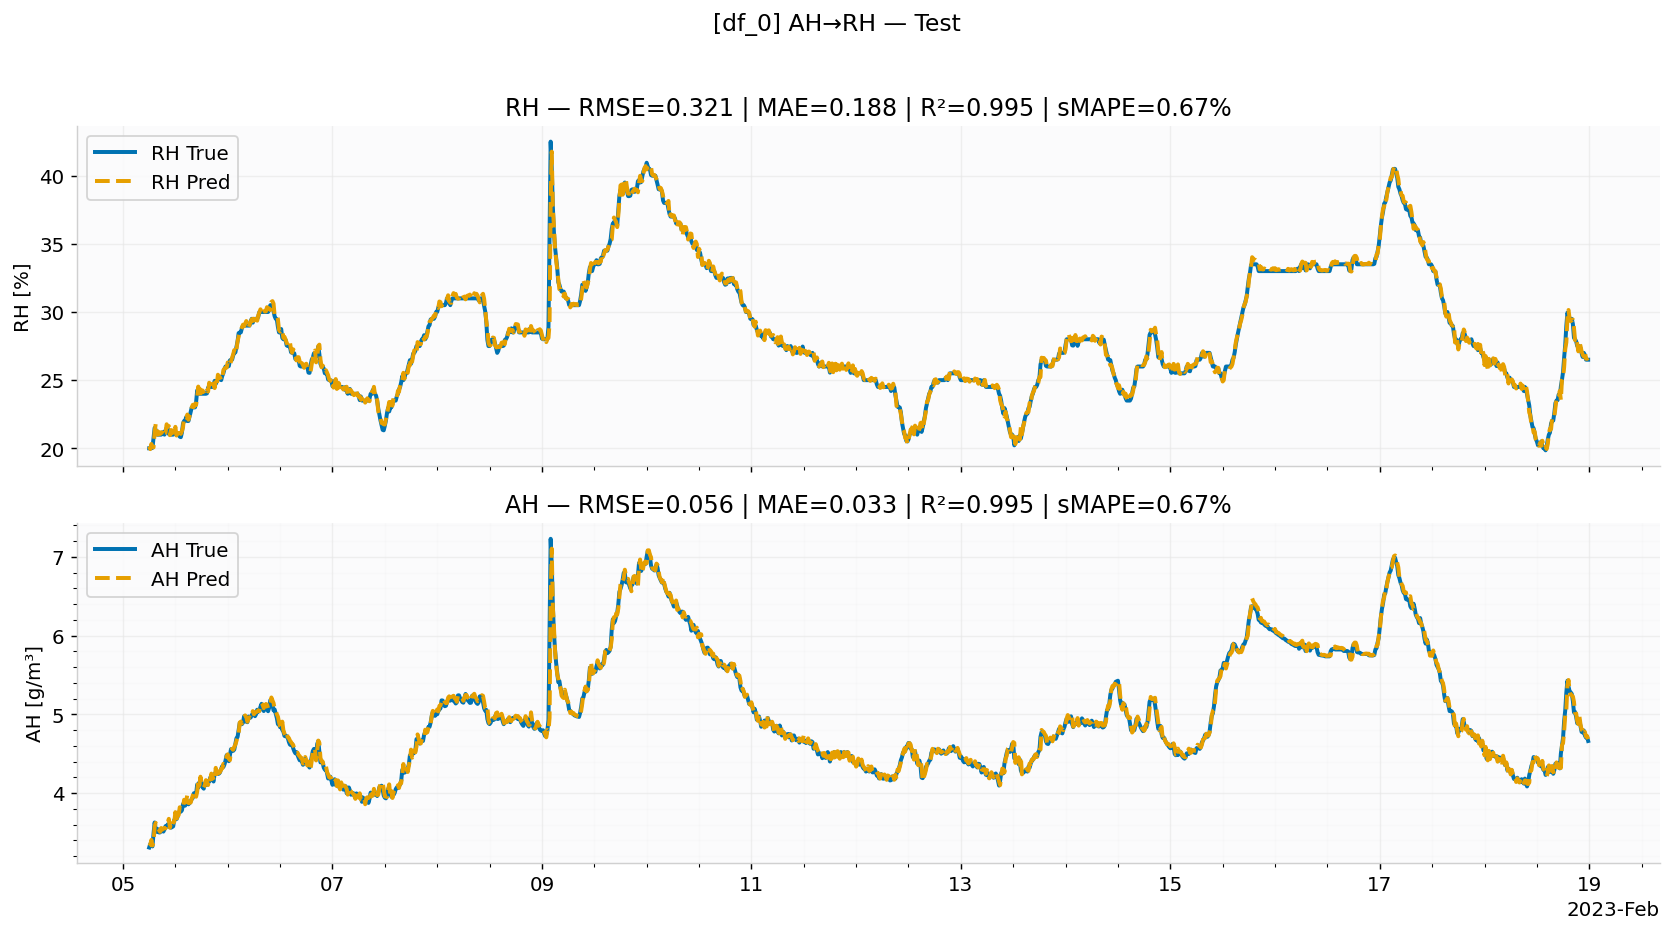

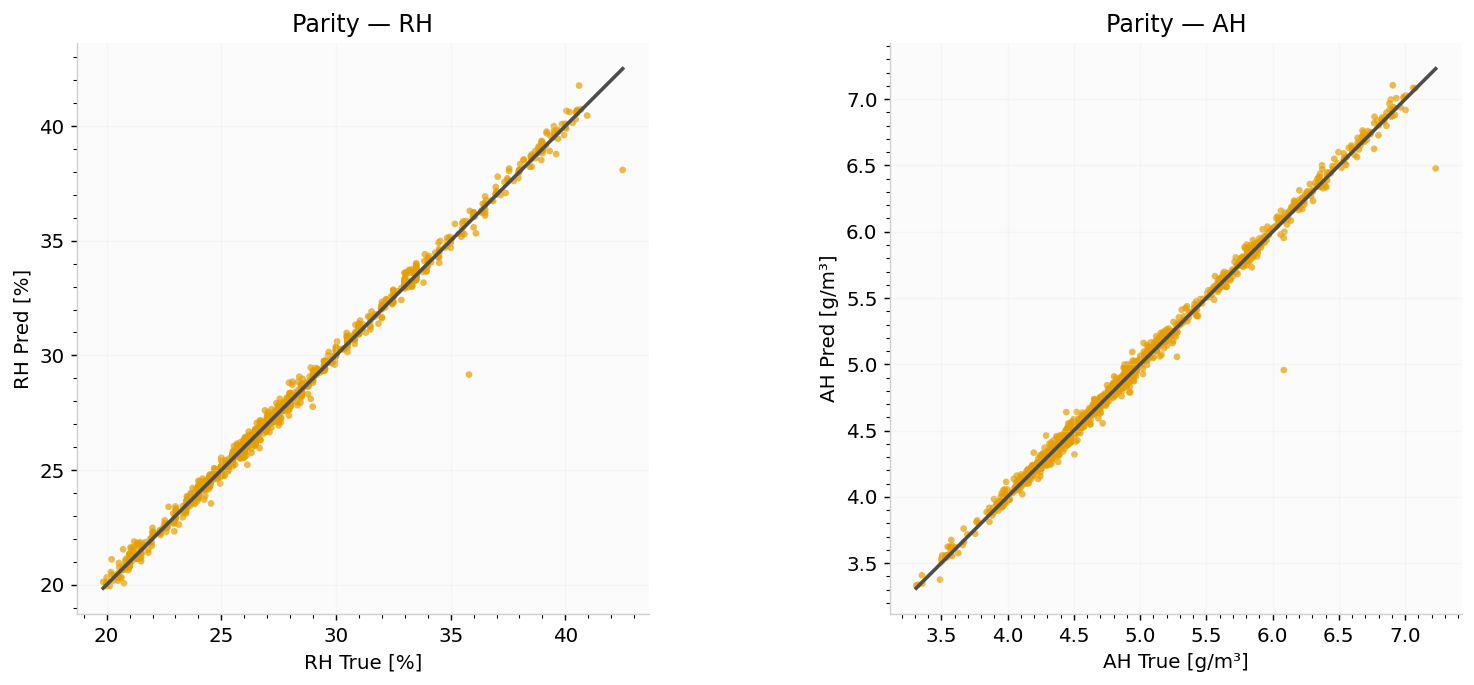

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_9144\678131728.py:258: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for b, sub in dfp.groupby(bins):



==== Test by HVAC mode ====
 mode   RH_MAE  RH_RMSE   AH_MAE  AH_RMSE   N
    0 0.187151 0.351408 0.033517 0.061419 906
    1 0.191580 0.245355 0.032990 0.042511 143
    2 0.187485 0.239204 0.032023 0.040903 271

==== Test by hour ====
 hour   RH_MAE  RH_RMSE   AH_MAE  AH_RMSE  N
    0 0.196099 0.237799 0.033794 0.040898 52
    1 0.307033 0.951120 0.052648 0.161809 52
    2 0.233497 0.654232 0.040020 0.111389 52
    3 0.144590 0.184158 0.024808 0.031558 52
    4 0.154649 0.195003 0.026524 0.033406 52
    5 0.144308 0.190084 0.024758 0.032626 52
    6 0.163343 0.200036 0.027954 0.034343 56
    7 0.171894 0.233668 0.029406 0.040010 56
    8 0.150138 0.183559 0.025687 0.031438 56
    9 0.199201 0.231146 0.034545 0.040035 56
   10 0.208619 0.271167 0.037246 0.048140 56
   11 0.203344 0.261082 0.037538 0.047412 56
   12 0.170318 0.239857 0.032634 0.047125 56
   13 0.208969 0.265391 0.040275 0.052208 56
   14 0.168782 0.207169 0.031342 0.038710 56
   15 0.165625 0.205437 0.030370 0.038315 5

c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


✅ Saved best model → models\df_1\best_ah.pt
🧪 Saved scaler → models/scalers\df_1\scaler_ah.pkl
Epoch 001 | RMSE (AH)=3.060 | val RMSE (AH)=0.656 | masked steps (train)=17624
✅ Saved best model → models\df_1\best_ah.pt
🧪 Saved scaler → models/scalers\df_1\scaler_ah.pkl
Epoch 002 | RMSE (AH)=0.638 | val RMSE (AH)=0.306 | masked steps (train)=17624
✅ Saved best model → models\df_1\best_ah.pt
🧪 Saved scaler → models/scalers\df_1\scaler_ah.pkl
Epoch 003 | RMSE (AH)=0.330 | val RMSE (AH)=0.282 | masked steps (train)=17624
✅ Saved best model → models\df_1\best_ah.pt
🧪 Saved scaler → models/scalers\df_1\scaler_ah.pkl
Epoch 004 | RMSE (AH)=0.264 | val RMSE (AH)=0.271 | masked steps (train)=17624
✅ Saved best model → models\df_1\best_ah.pt
🧪 Saved scaler → models/scalers\df_1\scaler_ah.pkl
Epoch 005 | RMSE (AH)=0.237 | val RMSE (AH)=0.256 | masked steps (train)=17624
✅ Saved best model → models\df_1\best_ah.pt
🧪 Saved scaler → models/scalers\df_1\scaler_ah.pkl
Epoch 006 | RMSE (AH)=0.220 | val R

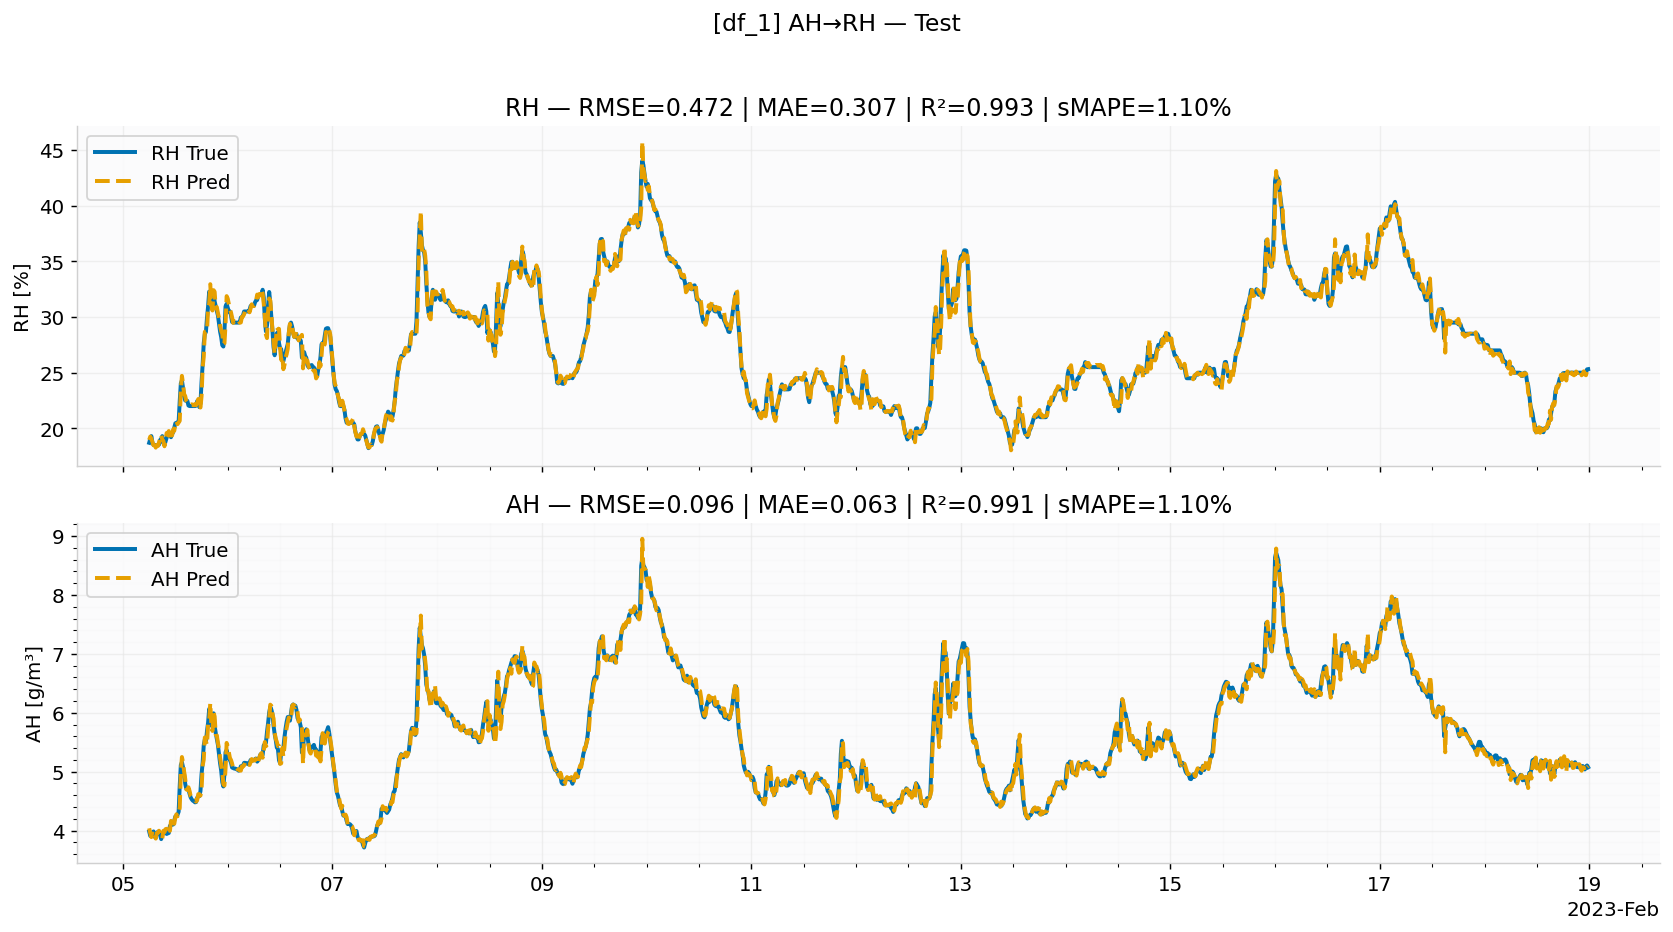

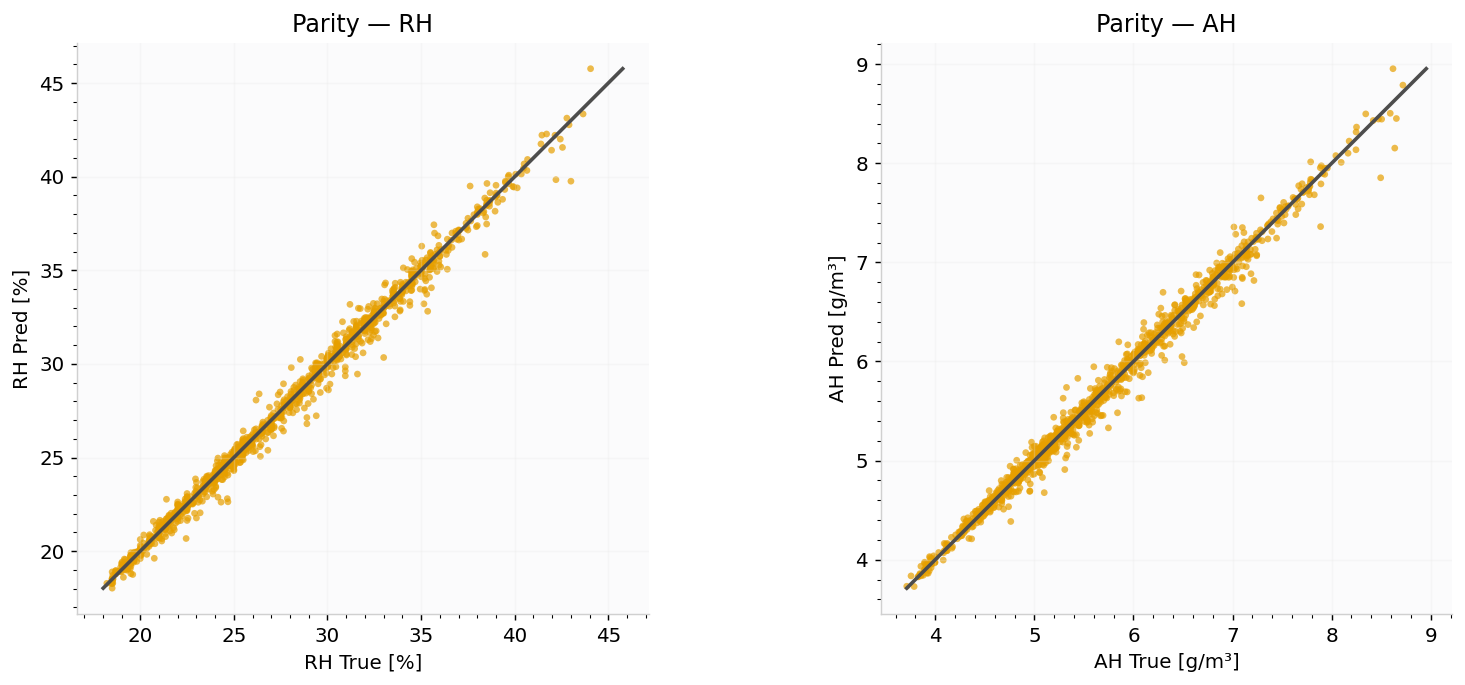

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_9144\678131728.py:258: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for b, sub in dfp.groupby(bins):



==== Test by HVAC mode ====
 mode   RH_MAE  RH_RMSE   AH_MAE  AH_RMSE   N
    0 0.548724 0.818446 0.111722 0.165565 150
    1 0.270805 0.406380 0.055697 0.083376 274
    2 0.278086 0.407313 0.056746 0.083453 896

==== Test by hour ====
 hour   RH_MAE  RH_RMSE   AH_MAE  AH_RMSE  N
    0 0.363625 0.513938 0.072431 0.103132 52
    1 0.278171 0.408522 0.055824 0.082852 52
    2 0.232756 0.312818 0.046271 0.062394 52
    3 0.237423 0.320086 0.047790 0.065576 52
    4 0.209496 0.285493 0.041889 0.057715 52
    5 0.184326 0.244056 0.036826 0.049502 52
    6 0.158531 0.208995 0.031198 0.040778 56
    7 0.177194 0.247546 0.034675 0.048392 56
    8 0.192615 0.232294 0.037746 0.045185 56
    9 0.217368 0.299621 0.043273 0.059160 56
   10 0.250605 0.329975 0.052504 0.069375 56
   11 0.386182 0.525876 0.082952 0.110611 56
   12 0.318713 0.432569 0.070733 0.097899 56
   13 0.477834 0.707085 0.104237 0.151772 56
   14 0.359068 0.531984 0.075869 0.109967 56
   15 0.274250 0.434520 0.057417 0.089754 5

c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


✅ Saved best model → models\df_2\best_ah.pt
🧪 Saved scaler → models/scalers\df_2\scaler_ah.pkl
Epoch 001 | RMSE (AH)=3.330 | val RMSE (AH)=0.959 | masked steps (train)=17624
✅ Saved best model → models\df_2\best_ah.pt
🧪 Saved scaler → models/scalers\df_2\scaler_ah.pkl
Epoch 002 | RMSE (AH)=0.910 | val RMSE (AH)=0.457 | masked steps (train)=17624
✅ Saved best model → models\df_2\best_ah.pt
🧪 Saved scaler → models/scalers\df_2\scaler_ah.pkl
Epoch 003 | RMSE (AH)=0.321 | val RMSE (AH)=0.245 | masked steps (train)=17624
✅ Saved best model → models\df_2\best_ah.pt
🧪 Saved scaler → models/scalers\df_2\scaler_ah.pkl
Epoch 004 | RMSE (AH)=0.263 | val RMSE (AH)=0.221 | masked steps (train)=17624
Epoch 005 | RMSE (AH)=0.236 | val RMSE (AH)=0.222 | masked steps (train)=17624
✅ Saved best model → models\df_2\best_ah.pt
🧪 Saved scaler → models/scalers\df_2\scaler_ah.pkl
Epoch 006 | RMSE (AH)=0.226 | val RMSE (AH)=0.204 | masked steps (train)=17624
Epoch 007 | RMSE (AH)=0.242 | val RMSE (AH)=0.207 |

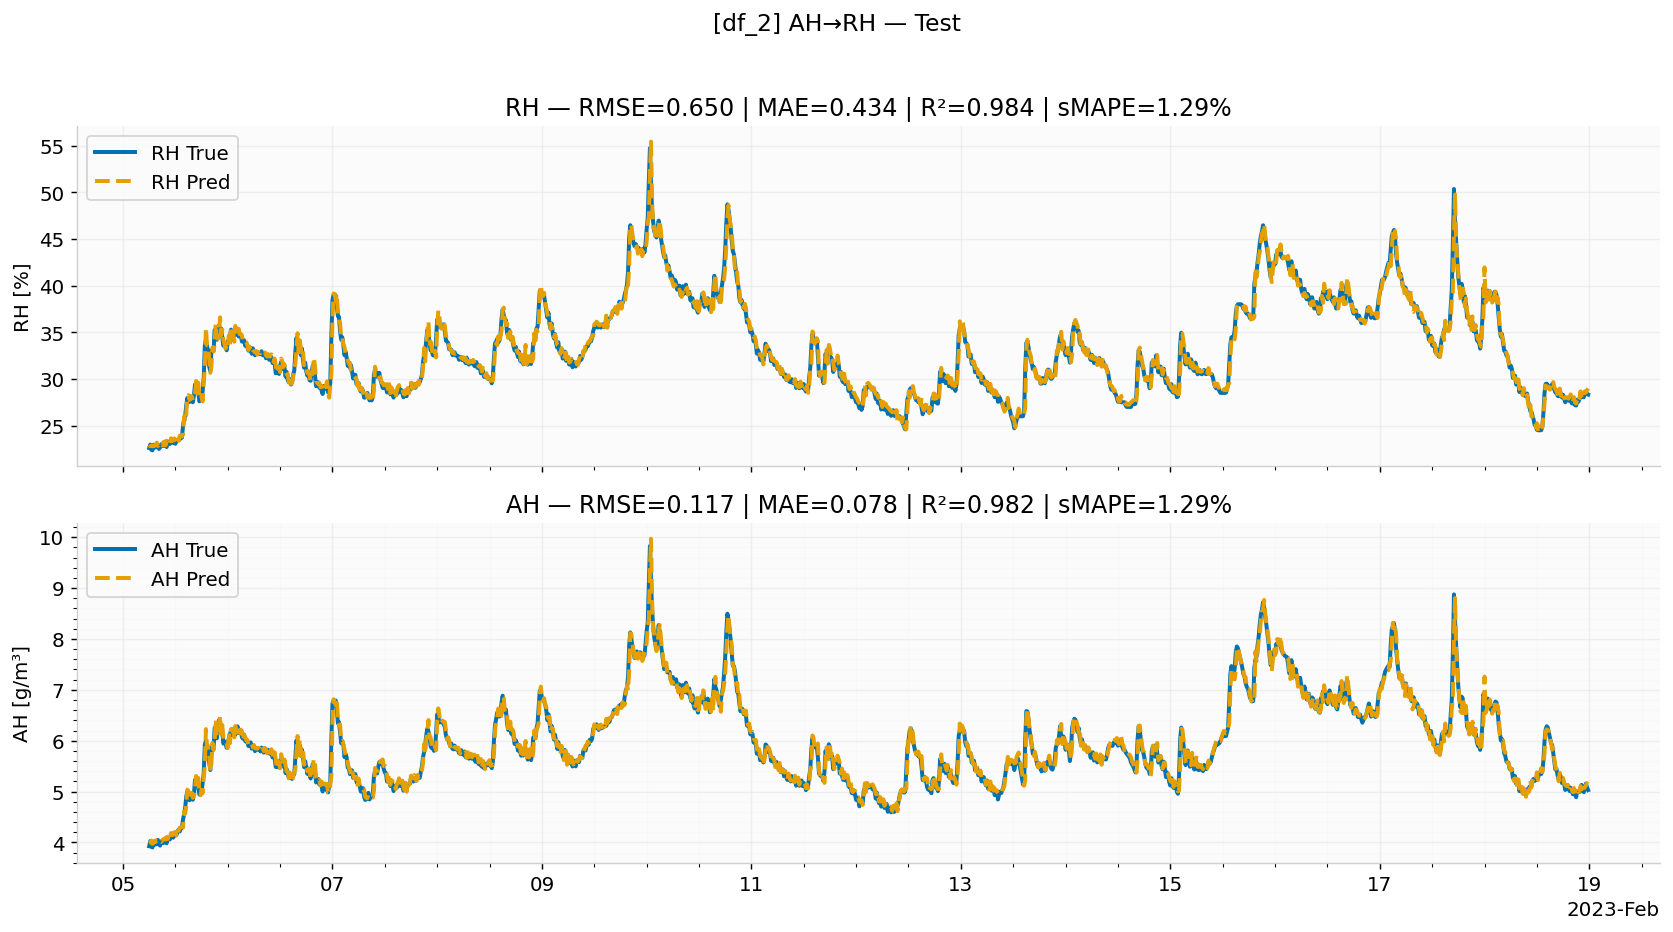

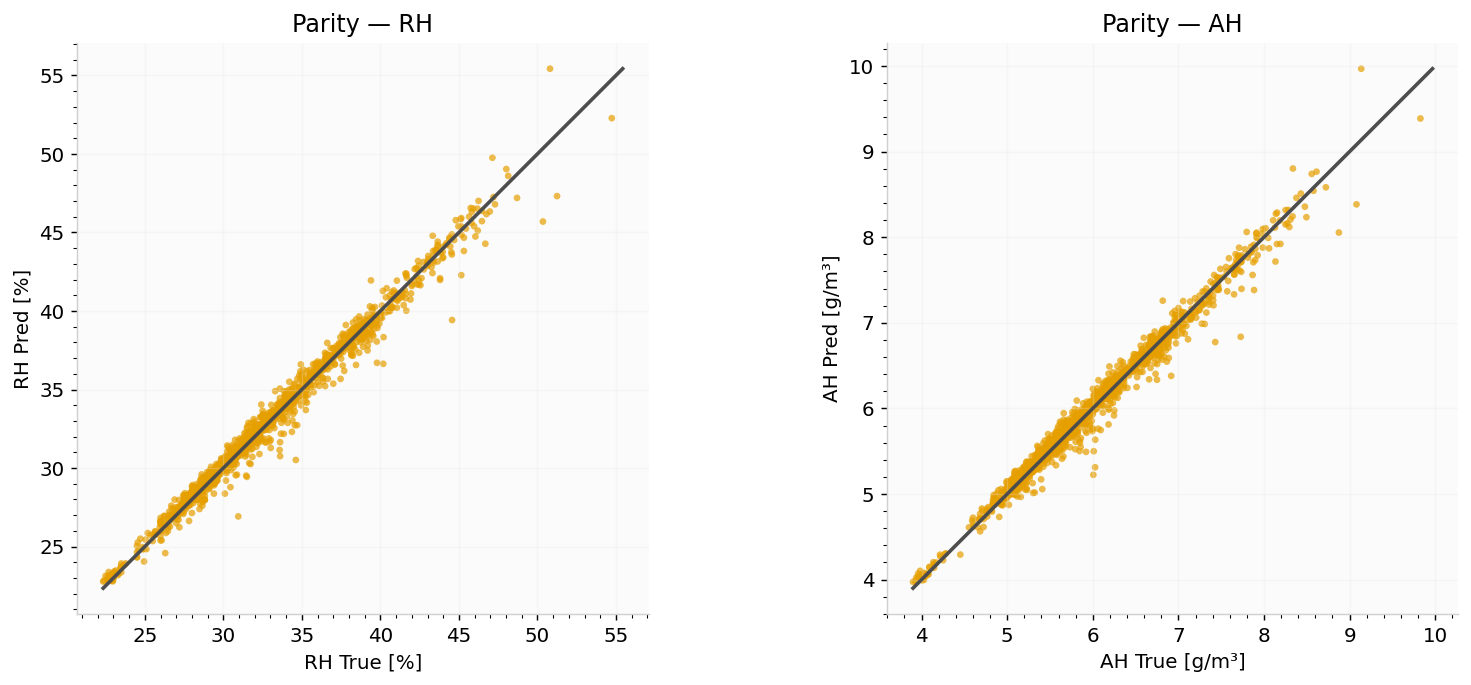

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_9144\678131728.py:258: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for b, sub in dfp.groupby(bins):



==== Test by HVAC mode ====
 mode   RH_MAE  RH_RMSE   AH_MAE  AH_RMSE   N
    0 0.507480 0.772437 0.092815 0.140261 559
    1 0.427028 0.614412 0.076135 0.109398 226
    2 0.359560 0.510942 0.063607 0.090163 535

==== Test by hour ====
 hour   RH_MAE  RH_RMSE   AH_MAE  AH_RMSE  N
    0 0.608967 0.927011 0.107629 0.163868 52
    1 0.618850 0.907555 0.109632 0.161962 52
    2 0.450555 0.689134 0.079665 0.122511 52
    3 0.435816 0.543395 0.076859 0.095919 52
    4 0.332874 0.388866 0.058578 0.068445 52
    5 0.306928 0.381119 0.054194 0.067337 52
    6 0.284152 0.348695 0.050220 0.061689 56
    7 0.309949 0.392252 0.054757 0.069431 56
    8 0.236535 0.303190 0.041815 0.053537 56
    9 0.252913 0.365705 0.045082 0.064792 56
   10 0.361770 0.446679 0.066845 0.082244 56
   11 0.332196 0.469075 0.062543 0.089781 56
   12 0.372966 0.445866 0.071264 0.085172 56
   13 0.471008 0.643220 0.090472 0.125155 56
   14 0.472992 0.738325 0.088740 0.140109 56
   15 0.471403 0.654731 0.086482 0.120140 5

c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


✅ Saved best model → models\df_3\best_ah.pt
🧪 Saved scaler → models/scalers\df_3\scaler_ah.pkl
Epoch 001 | RMSE (AH)=2.880 | val RMSE (AH)=0.531 | masked steps (train)=17624
✅ Saved best model → models\df_3\best_ah.pt
🧪 Saved scaler → models/scalers\df_3\scaler_ah.pkl
Epoch 002 | RMSE (AH)=0.462 | val RMSE (AH)=0.274 | masked steps (train)=17624
✅ Saved best model → models\df_3\best_ah.pt
🧪 Saved scaler → models/scalers\df_3\scaler_ah.pkl
Epoch 003 | RMSE (AH)=0.252 | val RMSE (AH)=0.201 | masked steps (train)=17624
✅ Saved best model → models\df_3\best_ah.pt
🧪 Saved scaler → models/scalers\df_3\scaler_ah.pkl
Epoch 004 | RMSE (AH)=0.213 | val RMSE (AH)=0.197 | masked steps (train)=17624
✅ Saved best model → models\df_3\best_ah.pt
🧪 Saved scaler → models/scalers\df_3\scaler_ah.pkl
Epoch 005 | RMSE (AH)=0.197 | val RMSE (AH)=0.180 | masked steps (train)=17624
✅ Saved best model → models\df_3\best_ah.pt
🧪 Saved scaler → models/scalers\df_3\scaler_ah.pkl
Epoch 006 | RMSE (AH)=0.181 | val R

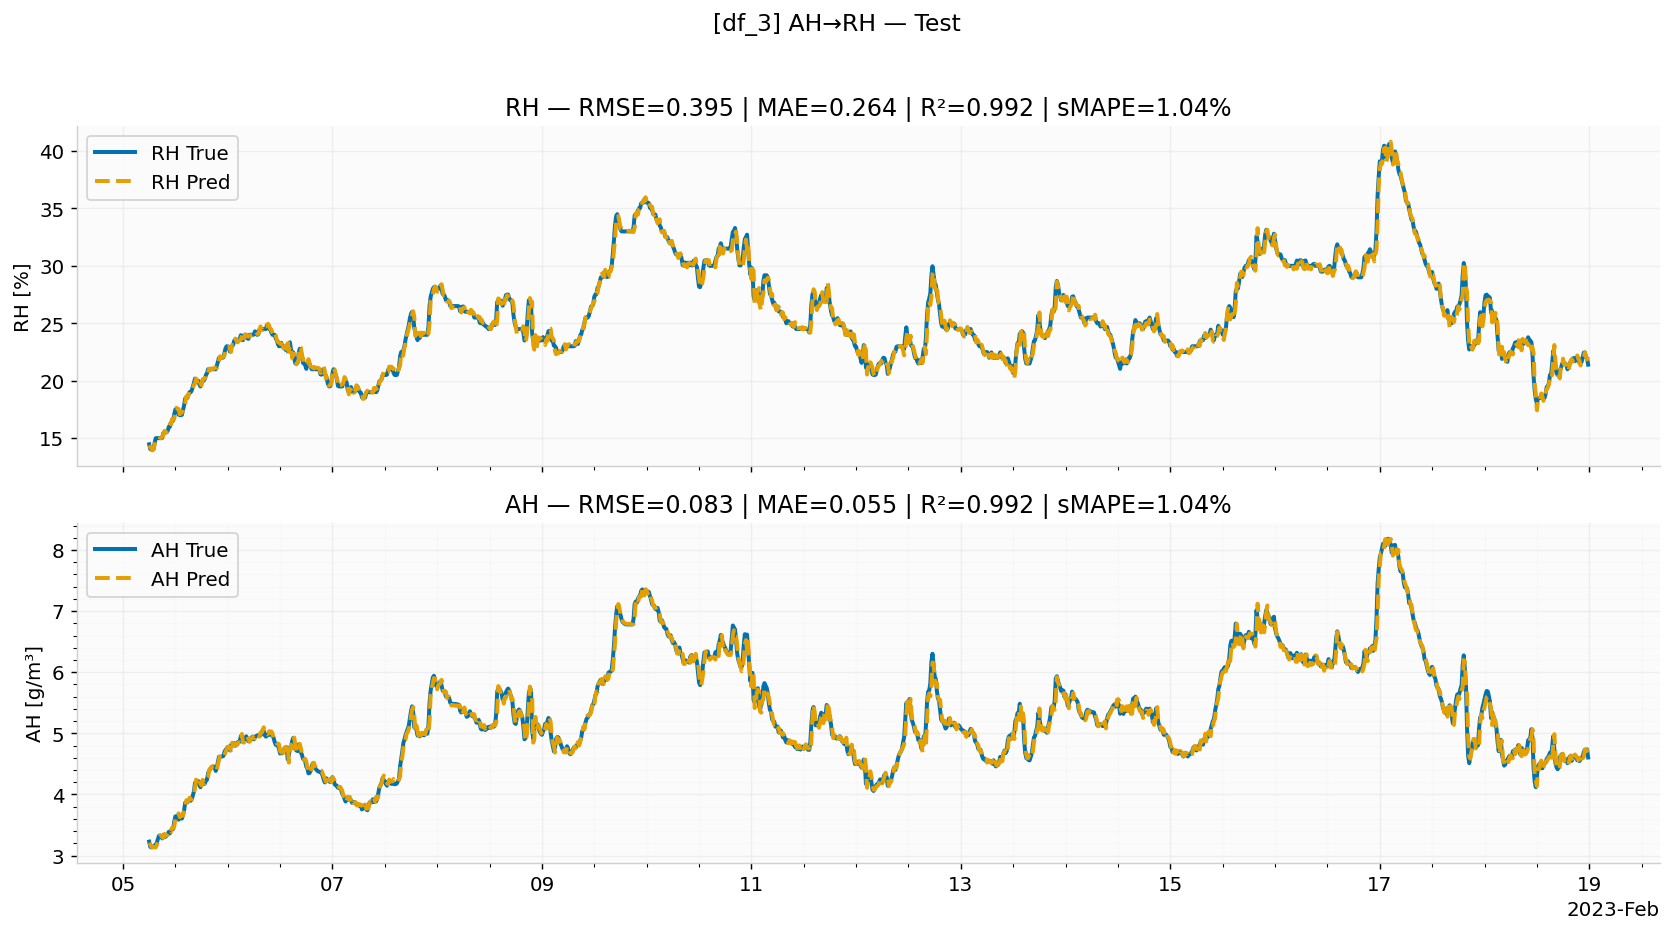

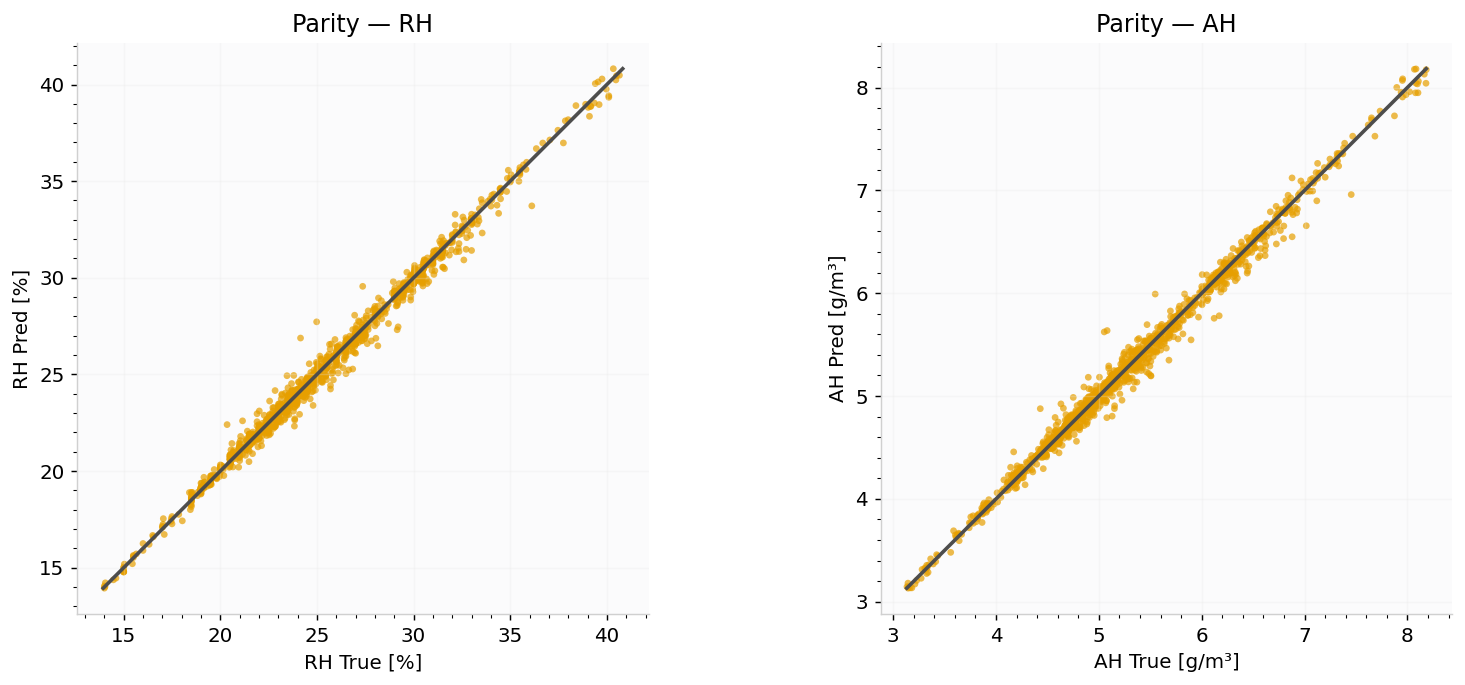

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_9144\678131728.py:258: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for b, sub in dfp.groupby(bins):



==== Test by HVAC mode ====
 mode   RH_MAE  RH_RMSE   AH_MAE  AH_RMSE   N
    0 0.445004 0.610394 0.096466 0.130475  77
    1 0.237482 0.352659 0.050245 0.074915 400
    2 0.259984 0.389043 0.053818 0.080555 843

==== Test by hour ====
 hour   RH_MAE  RH_RMSE   AH_MAE  AH_RMSE  N
    0 0.298642 0.456107 0.061391 0.093068 52
    1 0.258136 0.355829 0.053109 0.072870 52
    2 0.263180 0.387137 0.053655 0.078362 52
    3 0.271654 0.351191 0.055730 0.071918 52
    4 0.186386 0.258568 0.038136 0.053204 52
    5 0.159425 0.205686 0.032589 0.042196 52
    6 0.167379 0.224754 0.034151 0.045796 56
    7 0.169443 0.220011 0.034608 0.044770 56
    8 0.164035 0.206150 0.033481 0.042102 56
    9 0.179522 0.219307 0.036977 0.045302 56
   10 0.193882 0.254617 0.040722 0.053804 56
   11 0.286749 0.449394 0.062379 0.098104 56
   12 0.259737 0.332275 0.057745 0.074732 56
   13 0.331001 0.490244 0.071178 0.104517 56
   14 0.271693 0.365286 0.058256 0.078042 56
   15 0.286611 0.377931 0.061760 0.082792 5

c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


✅ Saved best model → models\df_4\best_ah.pt
🧪 Saved scaler → models/scalers\df_4\scaler_ah.pkl
Epoch 001 | RMSE (AH)=3.133 | val RMSE (AH)=0.493 | masked steps (train)=17624
✅ Saved best model → models\df_4\best_ah.pt
🧪 Saved scaler → models/scalers\df_4\scaler_ah.pkl
Epoch 002 | RMSE (AH)=0.484 | val RMSE (AH)=0.211 | masked steps (train)=17624
✅ Saved best model → models\df_4\best_ah.pt
🧪 Saved scaler → models/scalers\df_4\scaler_ah.pkl
Epoch 003 | RMSE (AH)=0.229 | val RMSE (AH)=0.105 | masked steps (train)=17624
Epoch 004 | RMSE (AH)=0.181 | val RMSE (AH)=0.111 | masked steps (train)=17624
Epoch 005 | RMSE (AH)=0.175 | val RMSE (AH)=0.125 | masked steps (train)=17624
✅ Saved best model → models\df_4\best_ah.pt
🧪 Saved scaler → models/scalers\df_4\scaler_ah.pkl
Epoch 006 | RMSE (AH)=0.152 | val RMSE (AH)=0.080 | masked steps (train)=17624
Epoch 007 | RMSE (AH)=0.152 | val RMSE (AH)=0.091 | masked steps (train)=17624
✅ Saved best model → models\df_4\best_ah.pt
🧪 Saved scaler → models

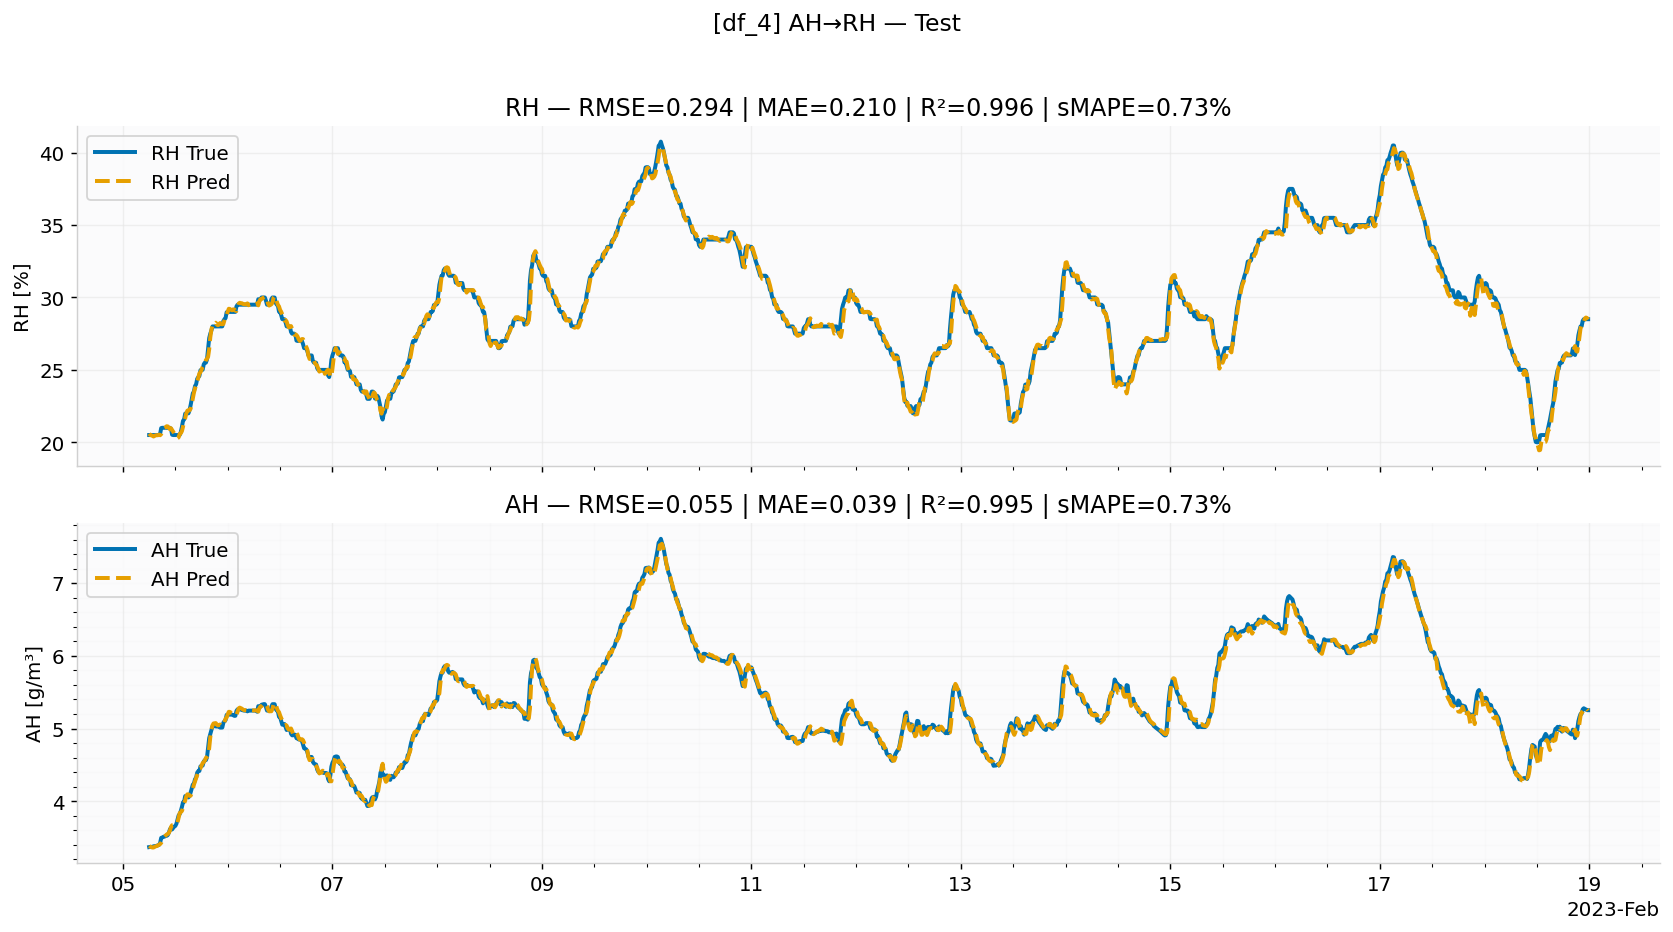

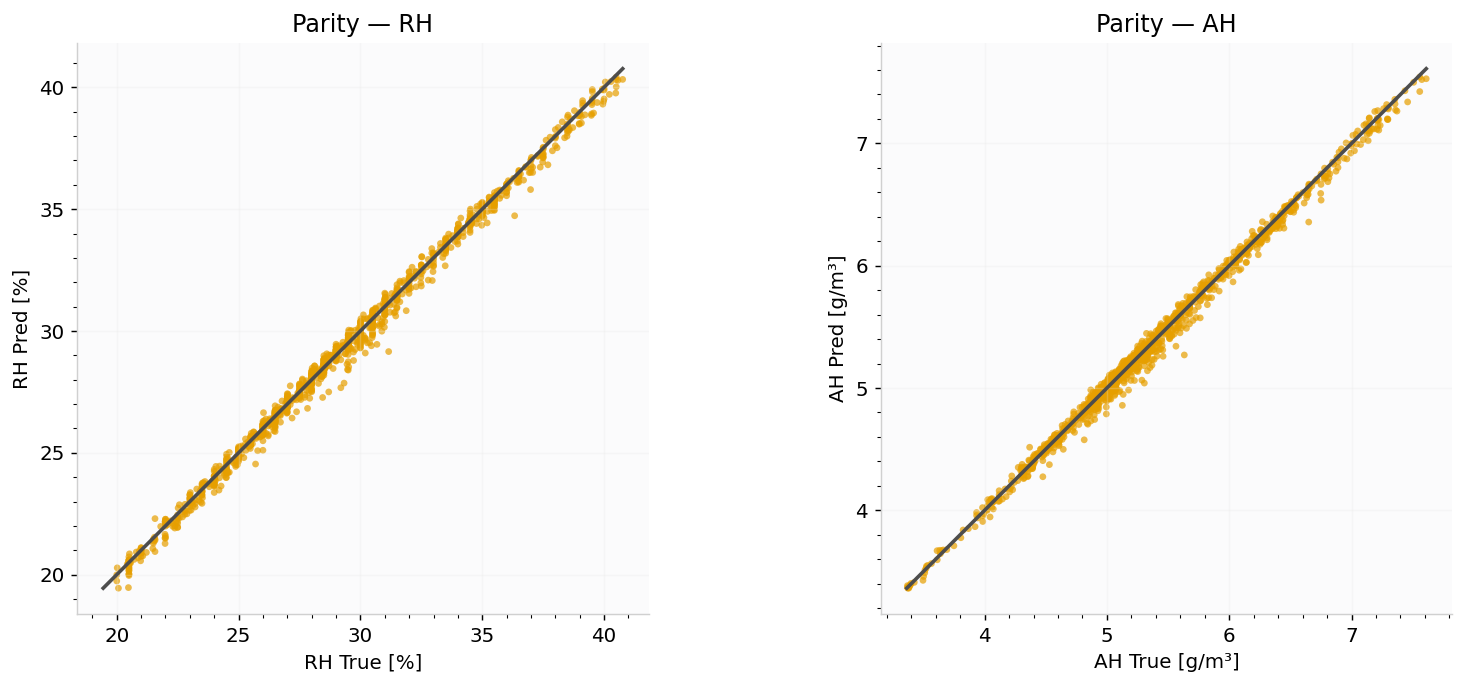

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_9144\678131728.py:258: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for b, sub in dfp.groupby(bins):



==== Test by HVAC mode ====
 mode   RH_MAE  RH_RMSE   AH_MAE  AH_RMSE    N
    0 0.200909 0.281022 0.037528 0.052843 1195
    1 0.295355 0.400919 0.051967 0.070653  125

==== Test by hour ====
 hour   RH_MAE  RH_RMSE   AH_MAE  AH_RMSE  N
    0 0.273892 0.353088 0.048984 0.063137 52
    1 0.217408 0.259002 0.038821 0.046267 52
    2 0.293417 0.420999 0.052870 0.076515 52
    3 0.199506 0.252442 0.035534 0.045112 52
    4 0.167278 0.223215 0.029737 0.039877 52
    5 0.130022 0.172542 0.022925 0.030440 52
    6 0.149441 0.186619 0.026372 0.033019 56
    7 0.131567 0.172214 0.023153 0.030422 56
    8 0.133575 0.176555 0.023417 0.030963 56
    9 0.158590 0.205219 0.028214 0.036492 56
   10 0.198426 0.246296 0.037331 0.046328 56
   11 0.218871 0.285348 0.044173 0.058459 56
   12 0.250814 0.319605 0.052346 0.069862 56
   13 0.231466 0.285645 0.046621 0.058006 56
   14 0.191709 0.244965 0.038808 0.050752 56
   15 0.214967 0.276248 0.042554 0.055400 56
   16 0.205989 0.274295 0.039277 0.052539

c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


✅ Saved best model → models\df_5\best_ah.pt
🧪 Saved scaler → models/scalers\df_5\scaler_ah.pkl
Epoch 001 | RMSE (AH)=2.781 | val RMSE (AH)=0.490 | masked steps (train)=17624
✅ Saved best model → models\df_5\best_ah.pt
🧪 Saved scaler → models/scalers\df_5\scaler_ah.pkl
Epoch 002 | RMSE (AH)=0.417 | val RMSE (AH)=0.232 | masked steps (train)=17624
✅ Saved best model → models\df_5\best_ah.pt
🧪 Saved scaler → models/scalers\df_5\scaler_ah.pkl
Epoch 003 | RMSE (AH)=0.232 | val RMSE (AH)=0.166 | masked steps (train)=17624
✅ Saved best model → models\df_5\best_ah.pt
🧪 Saved scaler → models/scalers\df_5\scaler_ah.pkl
Epoch 004 | RMSE (AH)=0.195 | val RMSE (AH)=0.150 | masked steps (train)=17624
✅ Saved best model → models\df_5\best_ah.pt
🧪 Saved scaler → models/scalers\df_5\scaler_ah.pkl
Epoch 005 | RMSE (AH)=0.171 | val RMSE (AH)=0.144 | masked steps (train)=17624
Epoch 006 | RMSE (AH)=0.163 | val RMSE (AH)=0.146 | masked steps (train)=17624
Epoch 007 | RMSE (AH)=0.154 | val RMSE (AH)=0.148 |

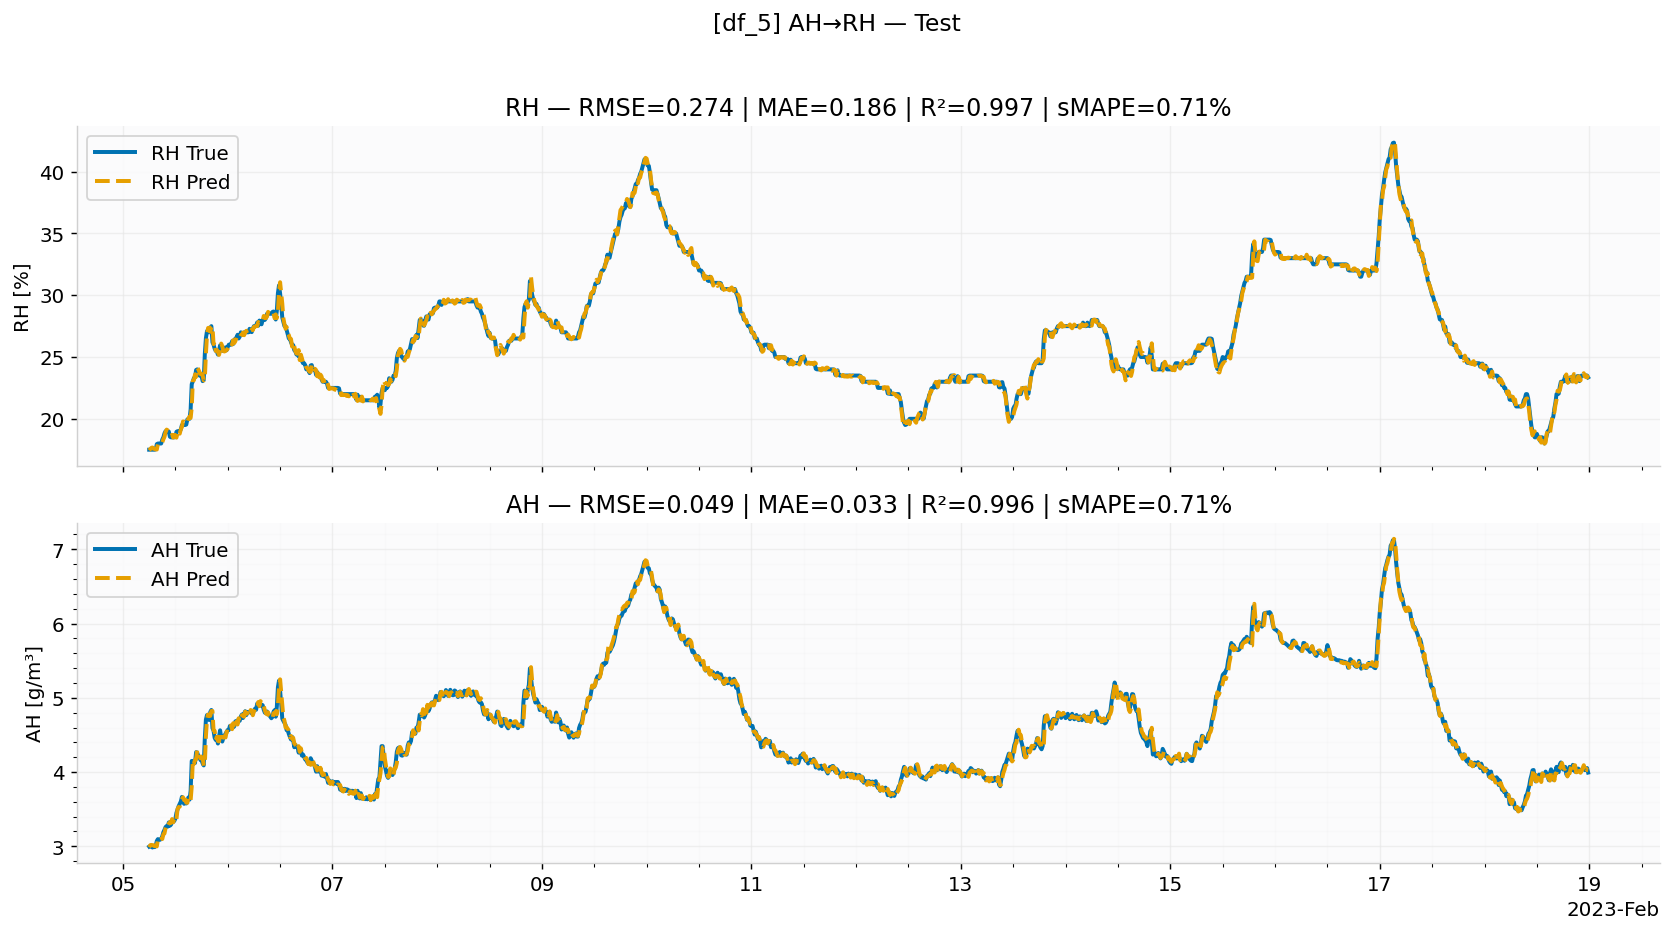

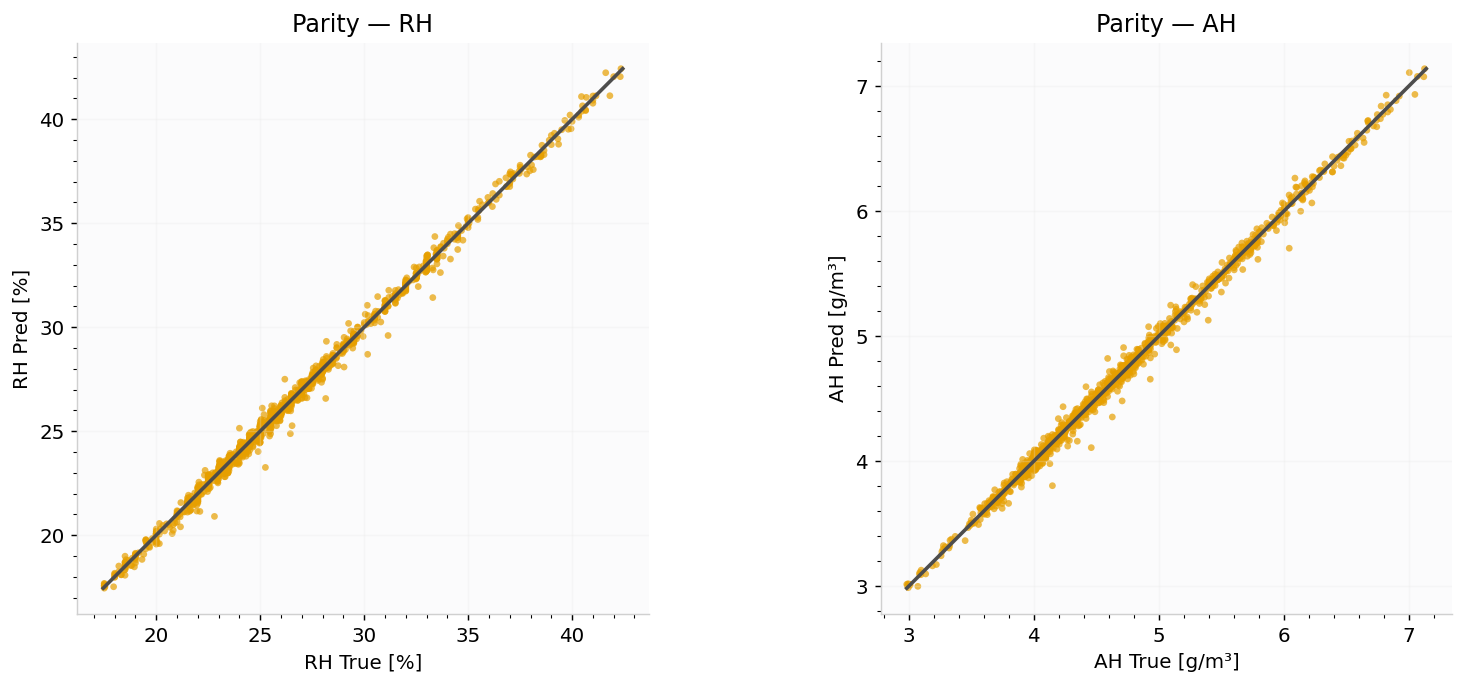

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_9144\678131728.py:258: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for b, sub in dfp.groupby(bins):



==== Test by HVAC mode ====
 mode   RH_MAE  RH_RMSE   AH_MAE  AH_RMSE   N
    0 0.199711 0.291872 0.035890 0.052641 746
    1 0.180638 0.281894 0.031209 0.049233 227
    2 0.160514 0.223035 0.027482 0.038301 347

==== Test by hour ====
 hour   RH_MAE  RH_RMSE   AH_MAE  AH_RMSE  N
    0 0.127563 0.166507 0.021793 0.028335 52
    1 0.184760 0.227123 0.031551 0.038752 52
    2 0.126115 0.177300 0.021514 0.030183 52
    3 0.147239 0.203197 0.025090 0.034556 52
    4 0.137315 0.166135 0.023414 0.028292 52
    5 0.146547 0.194422 0.024933 0.033048 52
    6 0.128435 0.171581 0.021889 0.029247 56
    7 0.133435 0.185020 0.022794 0.031553 56
    8 0.115669 0.159003 0.019702 0.027078 56
    9 0.201351 0.234025 0.034559 0.040258 56
   10 0.233261 0.281412 0.042392 0.051546 56
   11 0.257176 0.369614 0.048528 0.068712 56
   12 0.236580 0.337664 0.044264 0.062009 56
   13 0.174892 0.232609 0.033880 0.047038 56
   14 0.180782 0.235632 0.033207 0.042949 56
   15 0.224781 0.358100 0.041115 0.065530 5

c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


✅ Saved best model → models\df_6\best_ah.pt
🧪 Saved scaler → models/scalers\df_6\scaler_ah.pkl
Epoch 001 | RMSE (AH)=2.682 | val RMSE (AH)=0.363 | masked steps (train)=17624
✅ Saved best model → models\df_6\best_ah.pt
🧪 Saved scaler → models/scalers\df_6\scaler_ah.pkl
Epoch 002 | RMSE (AH)=0.484 | val RMSE (AH)=0.168 | masked steps (train)=17624
Epoch 003 | RMSE (AH)=0.242 | val RMSE (AH)=0.197 | masked steps (train)=17624
✅ Saved best model → models\df_6\best_ah.pt
🧪 Saved scaler → models/scalers\df_6\scaler_ah.pkl
Epoch 004 | RMSE (AH)=0.201 | val RMSE (AH)=0.164 | masked steps (train)=17624
✅ Saved best model → models\df_6\best_ah.pt
🧪 Saved scaler → models/scalers\df_6\scaler_ah.pkl
Epoch 005 | RMSE (AH)=0.192 | val RMSE (AH)=0.159 | masked steps (train)=17624
✅ Saved best model → models\df_6\best_ah.pt
🧪 Saved scaler → models/scalers\df_6\scaler_ah.pkl
Epoch 006 | RMSE (AH)=0.175 | val RMSE (AH)=0.147 | masked steps (train)=17624
✅ Saved best model → models\df_6\best_ah.pt
🧪 Saved

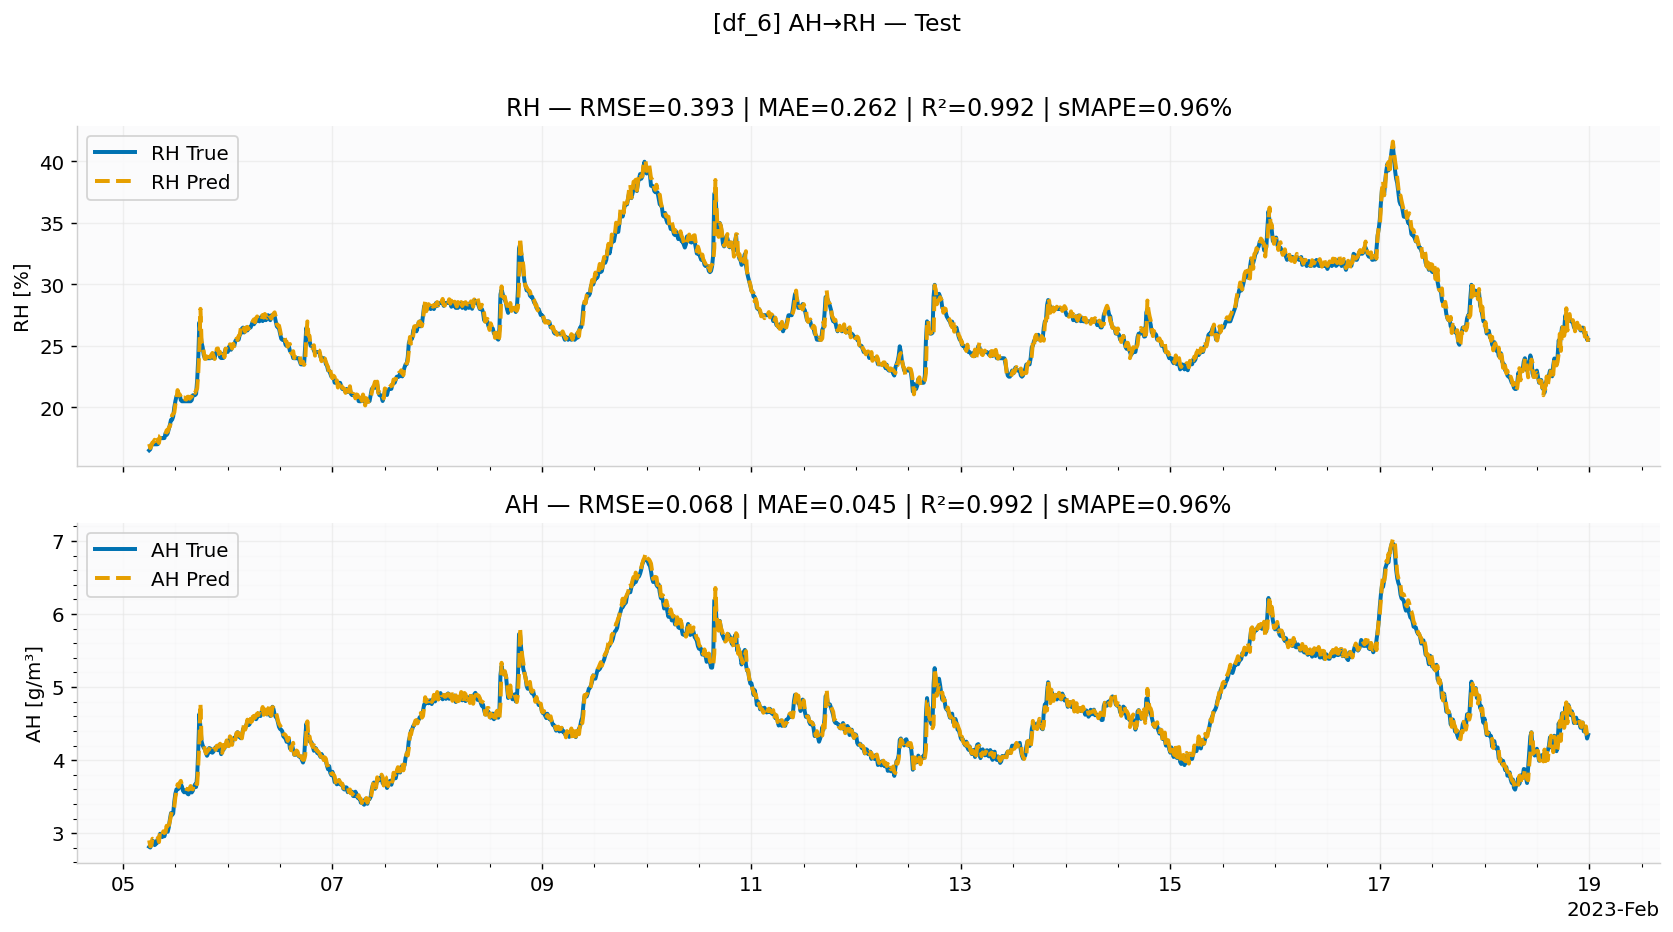

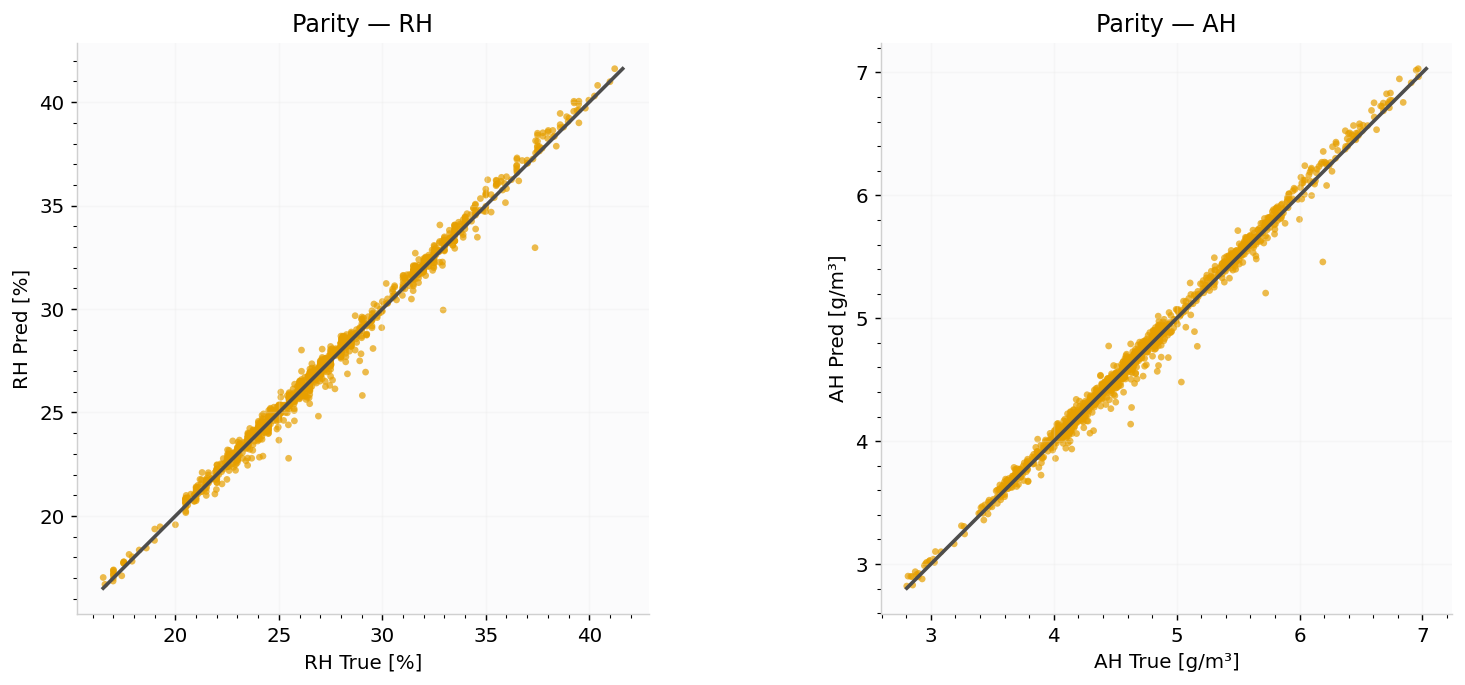

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_9144\678131728.py:258: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for b, sub in dfp.groupby(bins):



==== Test by HVAC mode ====
 mode   RH_MAE  RH_RMSE   AH_MAE  AH_RMSE   N
    0 0.296185 0.462517 0.051510 0.079919 508
    1 0.229772 0.319807 0.039481 0.055157 361
    2 0.249240 0.359901 0.042403 0.061504 451

==== Test by hour ====
 hour   RH_MAE  RH_RMSE   AH_MAE  AH_RMSE  N
    0 0.208060 0.263661 0.035525 0.044981 52
    1 0.221873 0.282037 0.037896 0.048249 52
    2 0.156411 0.227065 0.026770 0.038933 52
    3 0.256418 0.332782 0.043630 0.056693 52
    4 0.240705 0.291941 0.041037 0.049817 52
    5 0.215748 0.263915 0.036858 0.045149 52
    6 0.222026 0.285096 0.037873 0.048777 56
    7 0.235233 0.281448 0.039977 0.047848 56
    8 0.238688 0.294904 0.040494 0.049966 56
    9 0.223312 0.290788 0.037735 0.049037 56
   10 0.278177 0.381773 0.047943 0.065869 56
   11 0.240614 0.304154 0.042337 0.053621 56
   12 0.234258 0.272093 0.040981 0.047367 56
   13 0.241848 0.323783 0.042921 0.057684 56
   14 0.286240 0.439292 0.050640 0.077820 56
   15 0.309385 0.670592 0.053514 0.112456 5

c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


✅ Saved best model → models\df_7\best_ah.pt
🧪 Saved scaler → models/scalers\df_7\scaler_ah.pkl
Epoch 001 | RMSE (AH)=2.778 | val RMSE (AH)=0.393 | masked steps (train)=17624
✅ Saved best model → models\df_7\best_ah.pt
🧪 Saved scaler → models/scalers\df_7\scaler_ah.pkl
Epoch 002 | RMSE (AH)=0.478 | val RMSE (AH)=0.198 | masked steps (train)=17624
✅ Saved best model → models\df_7\best_ah.pt
🧪 Saved scaler → models/scalers\df_7\scaler_ah.pkl
Epoch 003 | RMSE (AH)=0.252 | val RMSE (AH)=0.189 | masked steps (train)=17624
Epoch 004 | RMSE (AH)=0.210 | val RMSE (AH)=0.225 | masked steps (train)=17624
✅ Saved best model → models\df_7\best_ah.pt
🧪 Saved scaler → models/scalers\df_7\scaler_ah.pkl
Epoch 005 | RMSE (AH)=0.188 | val RMSE (AH)=0.182 | masked steps (train)=17624
✅ Saved best model → models\df_7\best_ah.pt
🧪 Saved scaler → models/scalers\df_7\scaler_ah.pkl
Epoch 006 | RMSE (AH)=0.174 | val RMSE (AH)=0.170 | masked steps (train)=17624
Epoch 007 | RMSE (AH)=0.178 | val RMSE (AH)=0.188 |

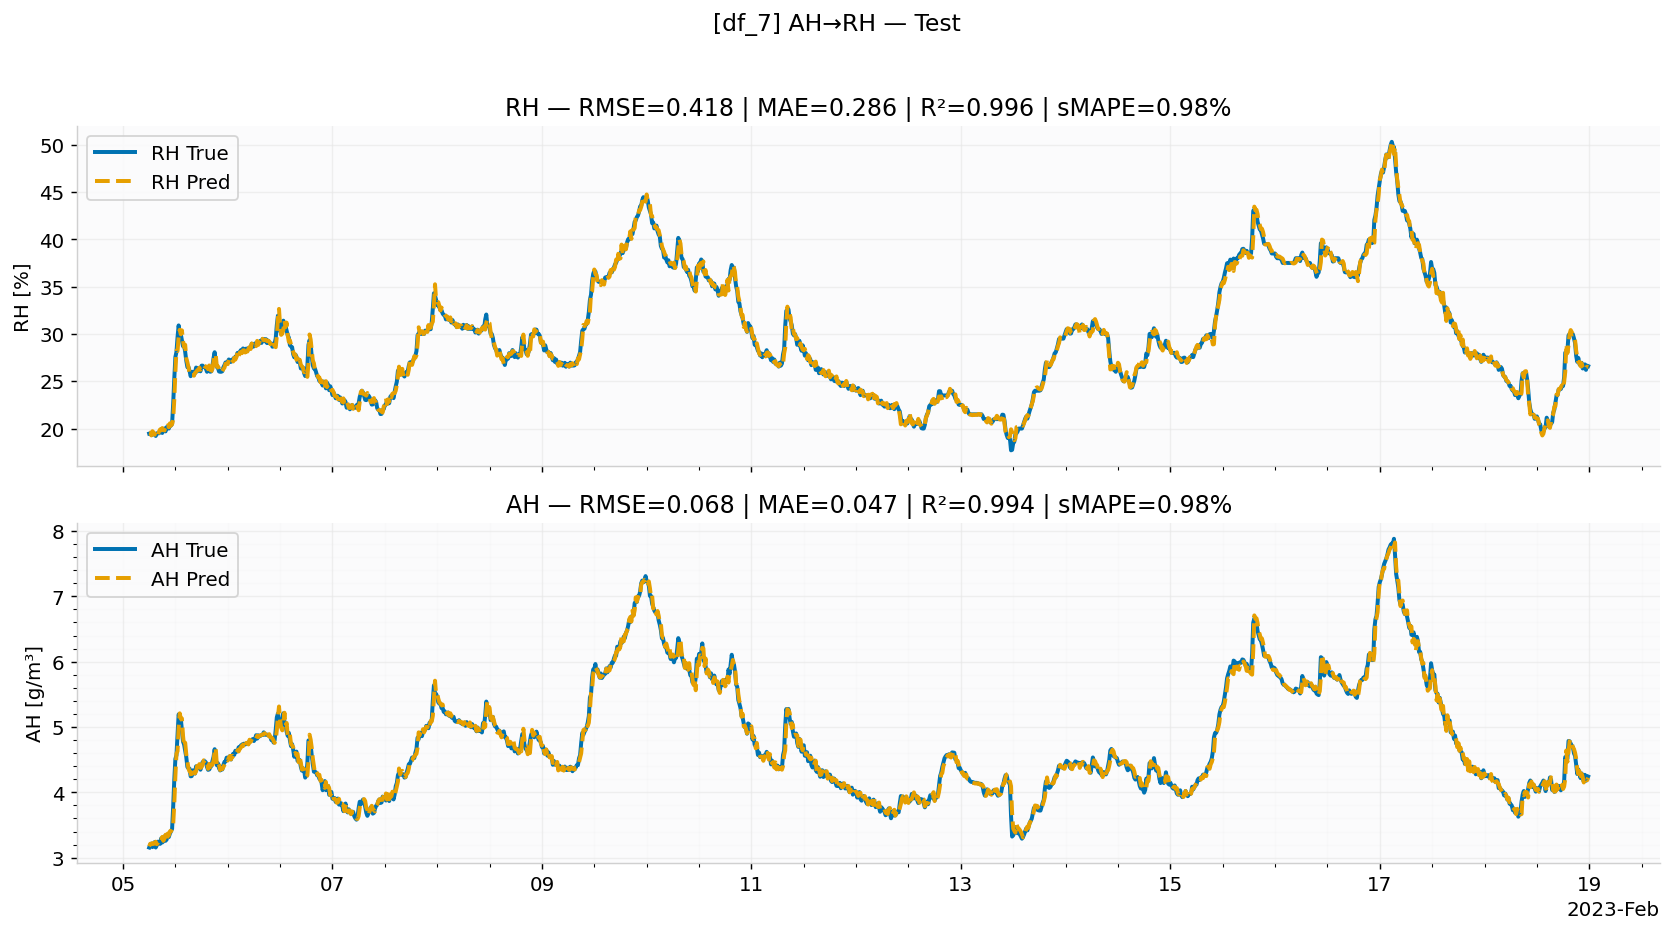

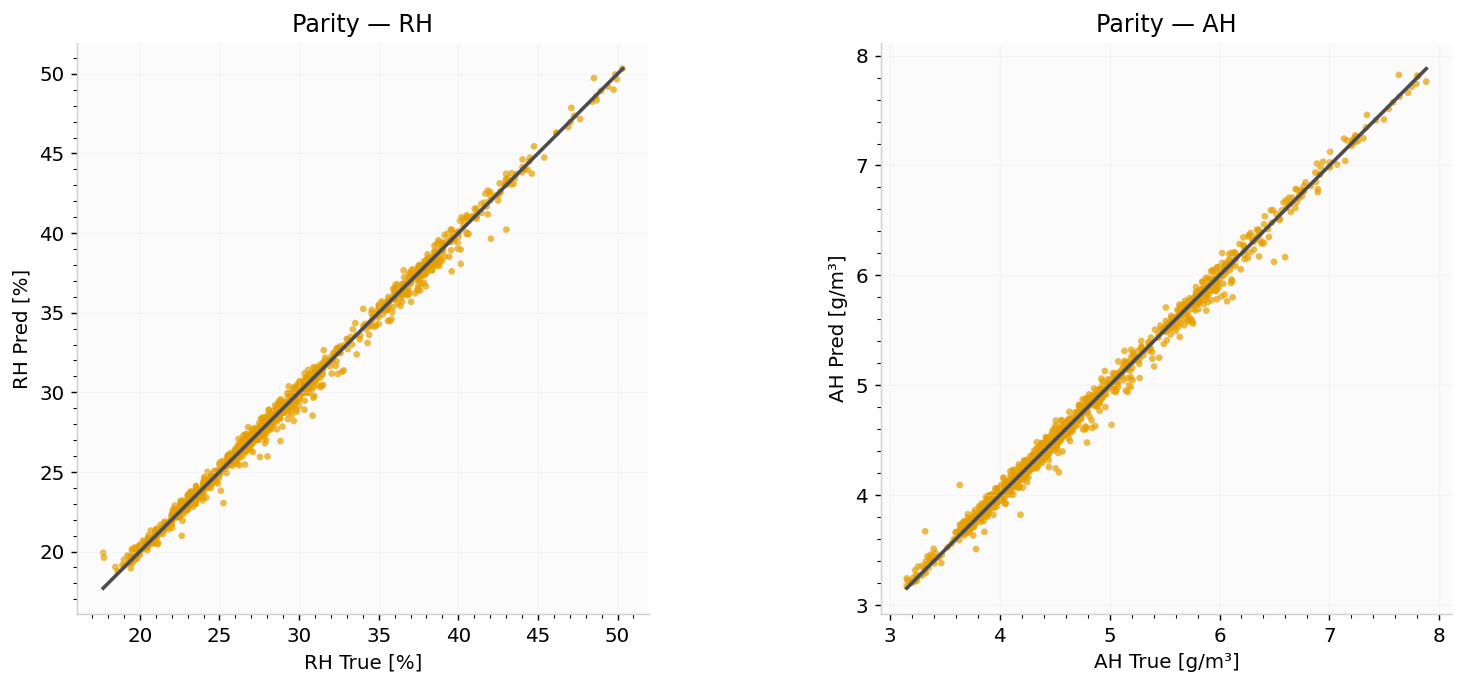


==== Test by HVAC mode ====
 mode   RH_MAE  RH_RMSE   AH_MAE  AH_RMSE   N
    0 0.338518 0.494879 0.053800 0.078834 411
    1 0.304000 0.434506 0.049981 0.072344 318
    2 0.239348 0.344280 0.039646 0.056950 591

==== Test by hour ====
 hour   RH_MAE  RH_RMSE   AH_MAE  AH_RMSE  N
    0 0.195338 0.249402 0.031489 0.040361 52
    1 0.212082 0.276400 0.034019 0.044240 52
    2 0.154016 0.203117 0.024732 0.032745 52
    3 0.221248 0.321304 0.035486 0.051243 52
    4 0.171346 0.241144 0.027349 0.038540 52
    5 0.169611 0.210097 0.027626 0.034560 52
    6 0.215168 0.307398 0.034042 0.047823 56
    7 0.302511 0.488222 0.048655 0.078826 56
    8 0.239676 0.353647 0.038295 0.056335 56
    9 0.274071 0.352687 0.044029 0.056671 56
   10 0.321386 0.478356 0.053511 0.077835 56
   11 0.606225 0.808594 0.102102 0.139213 56
   12 0.389415 0.528147 0.064653 0.087087 56
   13 0.325180 0.433536 0.054408 0.071467 56
   14 0.283218 0.378694 0.047309 0.062794 56
   15 0.272053 0.351280 0.045613 0.058236 5

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_9144\678131728.py:258: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for b, sub in dfp.groupby(bins):


In [24]:
run_ah_for_folder('datasets/retrofit/resampled', hvac_col="hvac_mode", save_root="models", win_ah=24)

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_22752\4185999809.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["hvac_mode"] = df["hvac_mode"].fillna(0).astype(int)
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_22752\4185999809.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["on_runtime_1h"] = df["on_runtime_1h"].fillna(0).astype(int)
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_22752\4185999809.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

✅ Saved best model → models/disaggregated\df_0\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_0\scaler_ah.pkl
Epoch 001 | RMSE (AH)=2.970 | val RMSE (AH)=0.571 | masked steps (train)=17544
✅ Saved best model → models/disaggregated\df_0\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_0\scaler_ah.pkl
Epoch 002 | RMSE (AH)=0.498 | val RMSE (AH)=0.399 | masked steps (train)=17544
✅ Saved best model → models/disaggregated\df_0\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_0\scaler_ah.pkl
Epoch 003 | RMSE (AH)=0.355 | val RMSE (AH)=0.286 | masked steps (train)=17544
✅ Saved best model → models/disaggregated\df_0\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_0\scaler_ah.pkl
Epoch 004 | RMSE (AH)=0.287 | val RMSE (AH)=0.271 | masked steps (train)=17544
Epoch 005 | RMSE (AH)=0.261 | val RMSE (AH)=0.391 | masked steps (train)=17544
Epoch 006 | RMSE (AH)=0.261 | val RMSE (AH)=0.288 | masked steps (train)=17544
✅ Saved best model → models/disagg

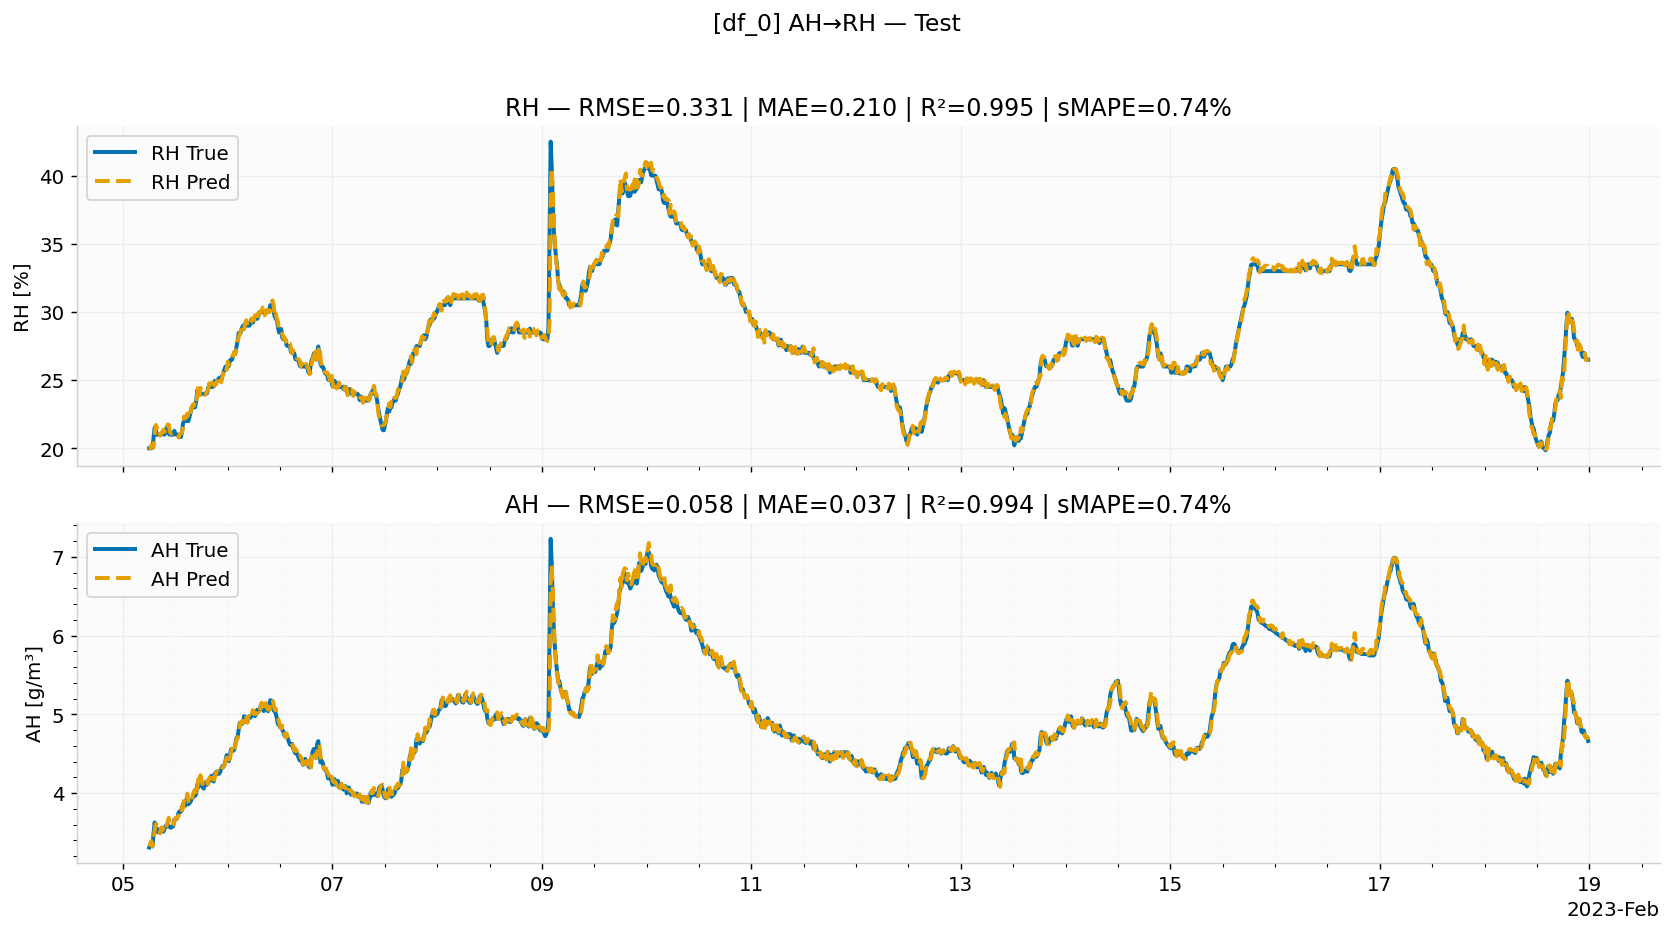

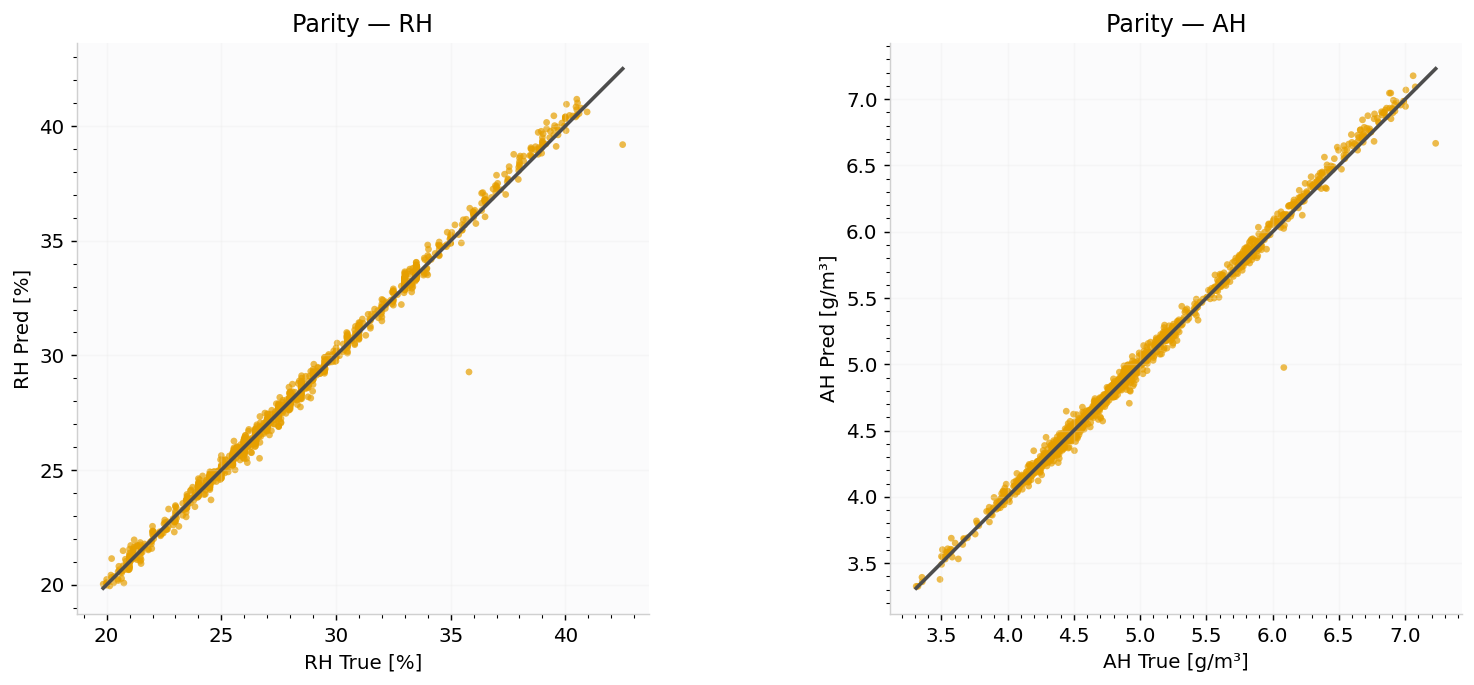

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_22752\678131728.py:258: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for b, sub in dfp.groupby(bins):
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_22752\4185999809.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["hvac_mode"] = df["hvac_mode"].fillna(0).astype(int)
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_22752\4185999809.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the d


==== Test by HVAC mode ====
 mode   RH_MAE  RH_RMSE   AH_MAE  AH_RMSE   N
    0 0.196225 0.275551 0.034997 0.049014 820
    1 0.219605 0.283373 0.038410 0.049571 162
    2 0.240605 0.453005 0.041679 0.077724 338

==== Test by hour ====
 hour   RH_MAE  RH_RMSE   AH_MAE  AH_RMSE  N
    0 0.226887 0.275404 0.039357 0.047842 52
    1 0.394656 0.963773 0.067897 0.164181 52
    2 0.241284 0.522965 0.041411 0.089129 52
    3 0.145642 0.198608 0.024982 0.034058 52
    4 0.185830 0.236902 0.031889 0.040708 52
    5 0.198964 0.263120 0.034253 0.045514 52
    6 0.164772 0.205796 0.028241 0.035368 56
    7 0.191098 0.244736 0.032649 0.041749 56
    8 0.158303 0.186622 0.027053 0.031856 56
    9 0.226984 0.270759 0.039426 0.047009 56
   10 0.239017 0.297063 0.042930 0.053227 56
   11 0.173144 0.232557 0.032047 0.042629 56
   12 0.185085 0.245726 0.035108 0.048450 56
   13 0.209469 0.271167 0.039690 0.051965 56
   14 0.183027 0.232242 0.034144 0.043463 56
   15 0.194208 0.240854 0.035353 0.044520 5

c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


✅ Saved best model → models/disaggregated\df_1\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_1\scaler_ah.pkl
Epoch 001 | RMSE (AH)=2.916 | val RMSE (AH)=0.506 | masked steps (train)=17544
✅ Saved best model → models/disaggregated\df_1\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_1\scaler_ah.pkl
Epoch 002 | RMSE (AH)=0.555 | val RMSE (AH)=0.338 | masked steps (train)=17544
✅ Saved best model → models/disaggregated\df_1\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_1\scaler_ah.pkl
Epoch 003 | RMSE (AH)=0.336 | val RMSE (AH)=0.290 | masked steps (train)=17544
✅ Saved best model → models/disaggregated\df_1\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_1\scaler_ah.pkl
Epoch 004 | RMSE (AH)=0.285 | val RMSE (AH)=0.276 | masked steps (train)=17544
✅ Saved best model → models/disaggregated\df_1\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_1\scaler_ah.pkl
Epoch 005 | RMSE (AH)=0.250 | val RMSE (AH)=0.259 | masked steps (tra

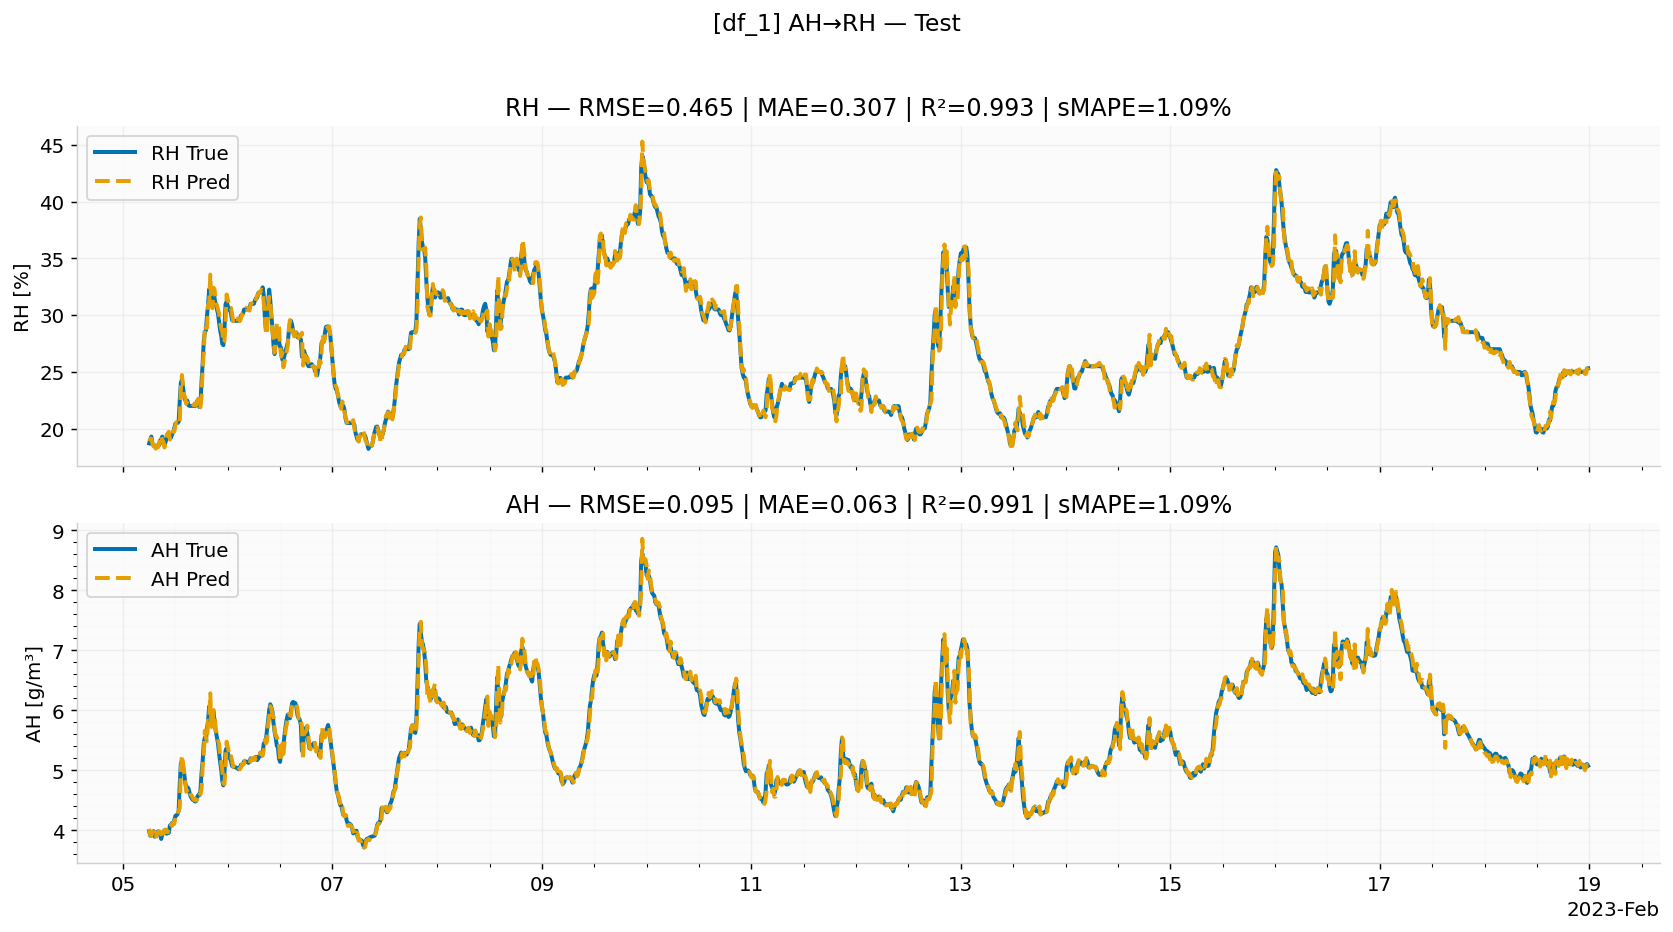

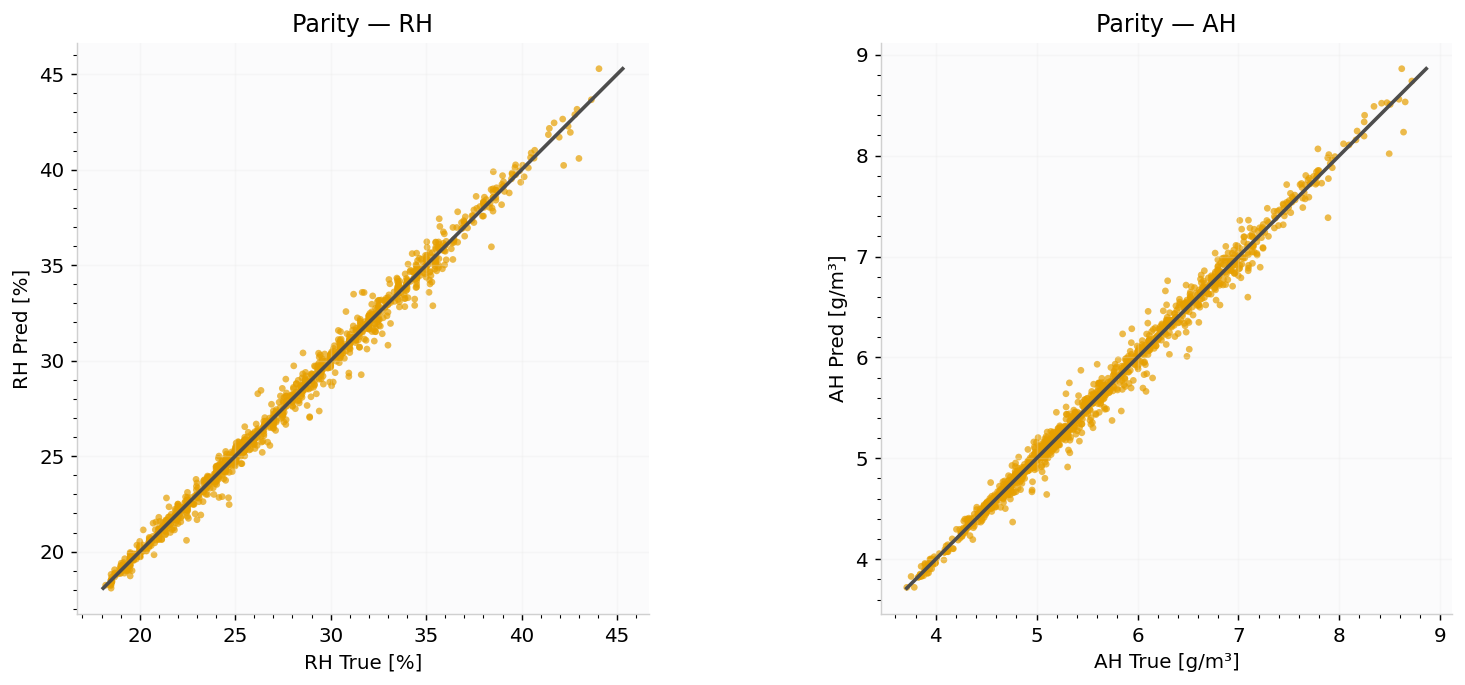

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_22752\678131728.py:258: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for b, sub in dfp.groupby(bins):
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_22752\4185999809.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["hvac_mode"] = df["hvac_mode"].fillna(0).astype(int)
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_22752\4185999809.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the d


==== Test by HVAC mode ====
 mode   RH_MAE  RH_RMSE   AH_MAE  AH_RMSE   N
    0 0.330690 0.504920 0.067595 0.102575 613
    1 0.225520 0.329360 0.046175 0.068493 264
    2 0.323385 0.476004 0.065589 0.096632 443

==== Test by hour ====
 hour   RH_MAE  RH_RMSE   AH_MAE  AH_RMSE  N
    0 0.331832 0.454081 0.066127 0.091334 52
    1 0.294477 0.432670 0.058825 0.087675 52
    2 0.250033 0.332012 0.049719 0.066345 52
    3 0.250226 0.334937 0.050434 0.068944 52
    4 0.243053 0.302889 0.048588 0.061132 52
    5 0.220766 0.272770 0.044128 0.055157 52
    6 0.155518 0.224554 0.030618 0.044296 56
    7 0.194233 0.269413 0.038257 0.053134 56
    8 0.213902 0.287572 0.041892 0.055992 56
    9 0.206100 0.297691 0.041140 0.059116 56
   10 0.275880 0.347983 0.057912 0.073406 56
   11 0.363818 0.517985 0.077188 0.106753 56
   12 0.292849 0.408296 0.064367 0.091738 56
   13 0.467563 0.685732 0.101824 0.146569 56
   14 0.402759 0.576043 0.085120 0.119032 56
   15 0.282007 0.425251 0.059298 0.087611 5

c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


✅ Saved best model → models/disaggregated\df_2\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_2\scaler_ah.pkl
Epoch 001 | RMSE (AH)=3.272 | val RMSE (AH)=0.808 | masked steps (train)=17544
✅ Saved best model → models/disaggregated\df_2\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_2\scaler_ah.pkl
Epoch 002 | RMSE (AH)=0.709 | val RMSE (AH)=0.274 | masked steps (train)=17544
✅ Saved best model → models/disaggregated\df_2\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_2\scaler_ah.pkl
Epoch 003 | RMSE (AH)=0.293 | val RMSE (AH)=0.240 | masked steps (train)=17544
✅ Saved best model → models/disaggregated\df_2\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_2\scaler_ah.pkl
Epoch 004 | RMSE (AH)=0.255 | val RMSE (AH)=0.239 | masked steps (train)=17544
✅ Saved best model → models/disaggregated\df_2\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_2\scaler_ah.pkl
Epoch 005 | RMSE (AH)=0.232 | val RMSE (AH)=0.217 | masked steps (tra

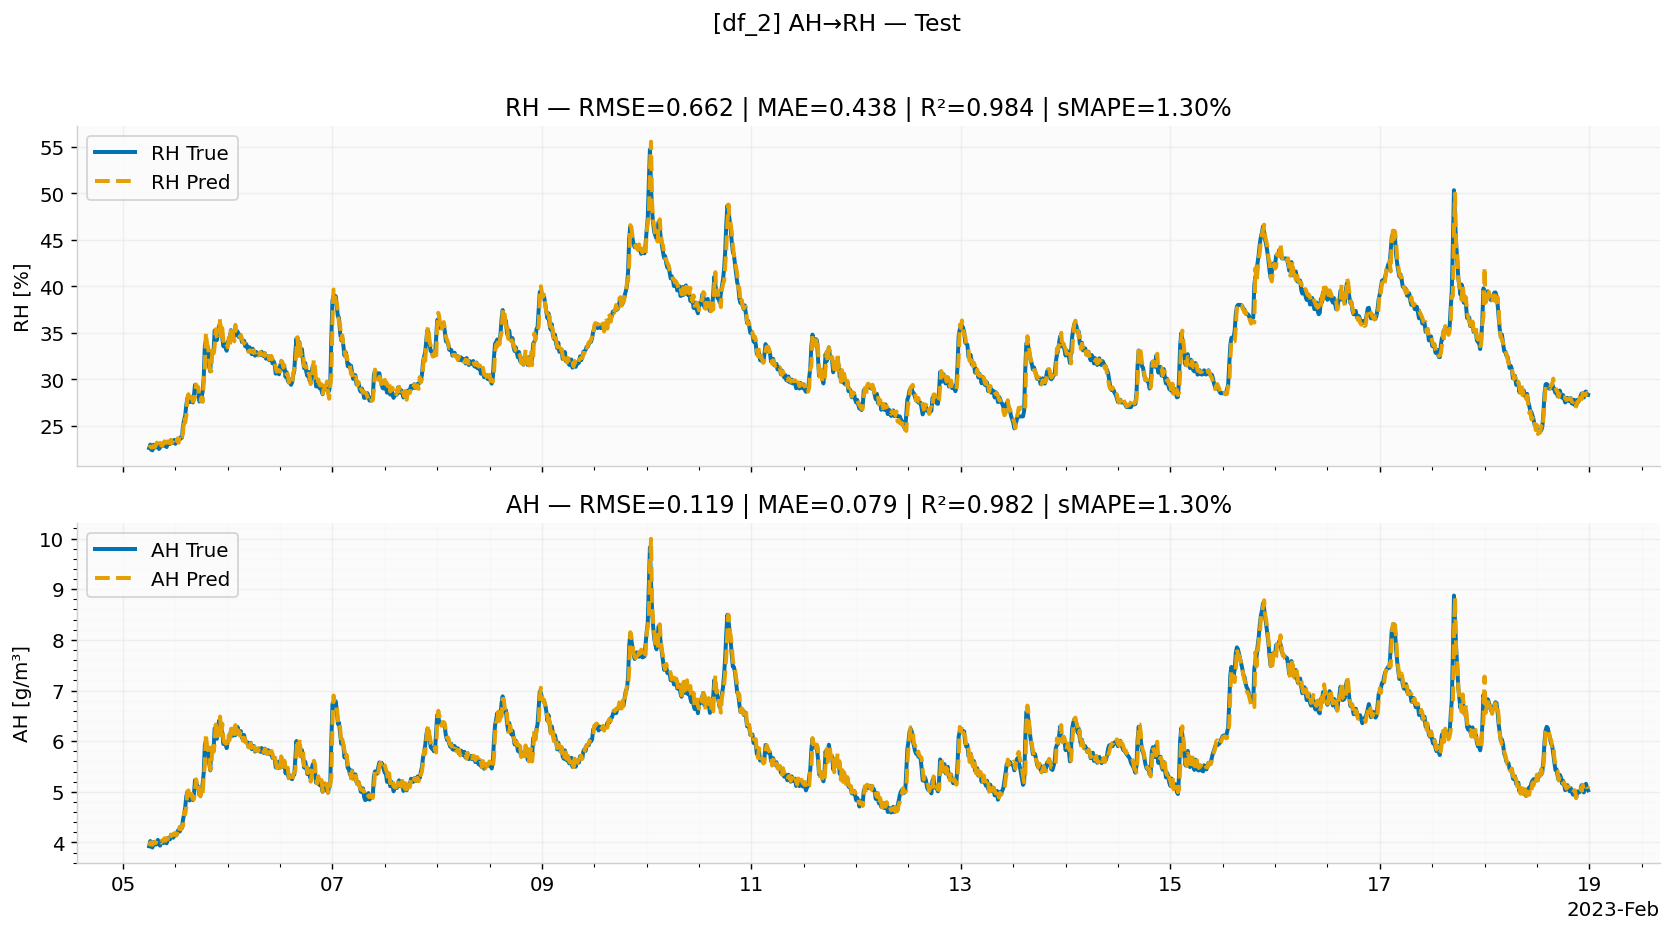

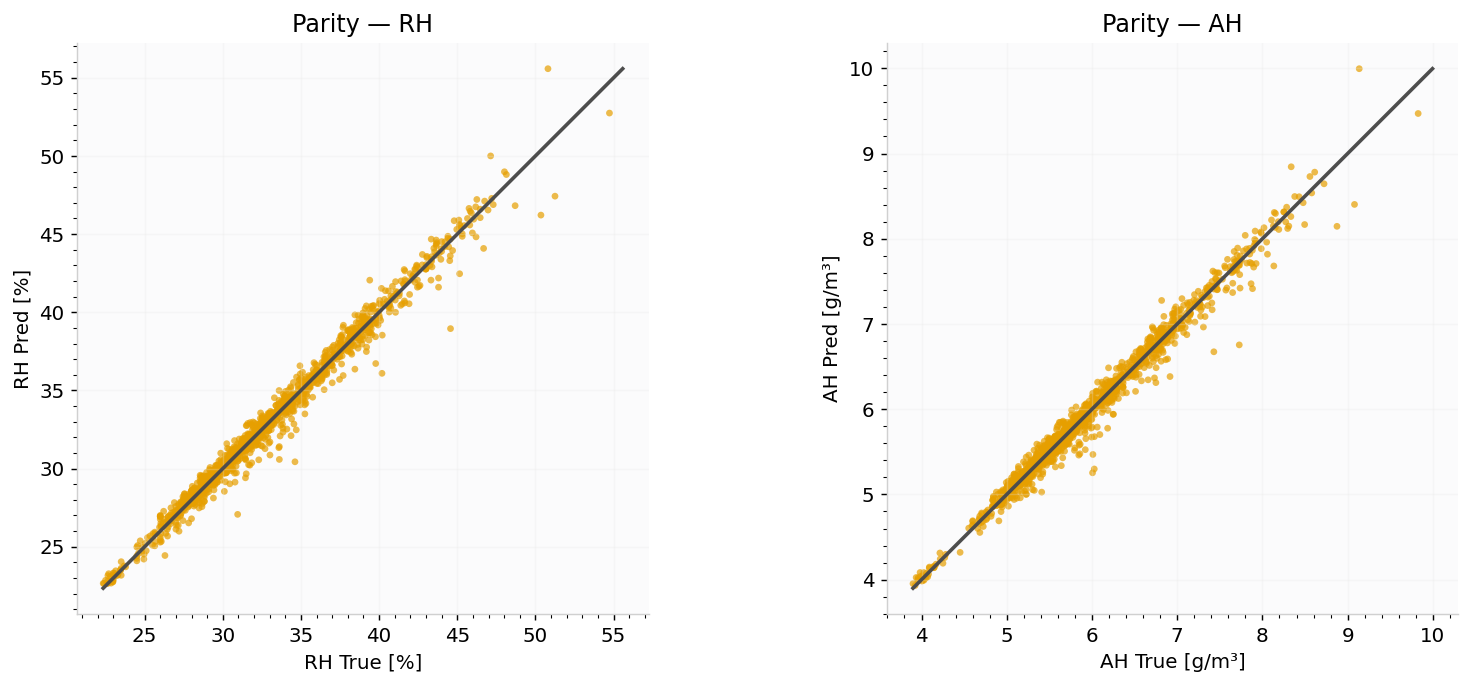

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_22752\678131728.py:258: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for b, sub in dfp.groupby(bins):
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_22752\4185999809.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["hvac_mode"] = df["hvac_mode"].fillna(0).astype(int)
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_22752\4185999809.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the d


==== Test by HVAC mode ====
 mode   RH_MAE  RH_RMSE   AH_MAE  AH_RMSE   N
    0 0.446109 0.638619 0.081657 0.116947 647
    1 0.338098 0.425632 0.060916 0.076847  44
    2 0.436232 0.697643 0.077535 0.123893 629

==== Test by hour ====
 hour   RH_MAE  RH_RMSE   AH_MAE  AH_RMSE  N
    0 0.568515 0.889330 0.100489 0.157068 52
    1 0.603307 0.914496 0.106985 0.163361 52
    2 0.450898 0.699955 0.079701 0.124380 52
    3 0.448969 0.541446 0.079218 0.095675 52
    4 0.316149 0.392894 0.055661 0.069188 52
    5 0.280528 0.347925 0.049550 0.061521 52
    6 0.265933 0.330685 0.047042 0.058600 56
    7 0.274382 0.360897 0.048472 0.063825 56
    8 0.284374 0.361222 0.050273 0.063900 56
    9 0.324174 0.432018 0.058096 0.077203 56
   10 0.415331 0.520942 0.076966 0.096185 56
   11 0.322873 0.478613 0.061354 0.092444 56
   12 0.329940 0.403481 0.063028 0.076763 56
   13 0.524782 0.721902 0.101309 0.140356 56
   14 0.469096 0.750649 0.088232 0.142702 56
   15 0.525288 0.677741 0.097091 0.125496 5

c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


✅ Saved best model → models/disaggregated\df_3\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_3\scaler_ah.pkl
Epoch 001 | RMSE (AH)=2.872 | val RMSE (AH)=0.496 | masked steps (train)=17544
✅ Saved best model → models/disaggregated\df_3\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_3\scaler_ah.pkl
Epoch 002 | RMSE (AH)=0.405 | val RMSE (AH)=0.259 | masked steps (train)=17544
✅ Saved best model → models/disaggregated\df_3\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_3\scaler_ah.pkl
Epoch 003 | RMSE (AH)=0.249 | val RMSE (AH)=0.219 | masked steps (train)=17544
✅ Saved best model → models/disaggregated\df_3\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_3\scaler_ah.pkl
Epoch 004 | RMSE (AH)=0.202 | val RMSE (AH)=0.190 | masked steps (train)=17544
✅ Saved best model → models/disaggregated\df_3\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_3\scaler_ah.pkl
Epoch 005 | RMSE (AH)=0.182 | val RMSE (AH)=0.180 | masked steps (tra

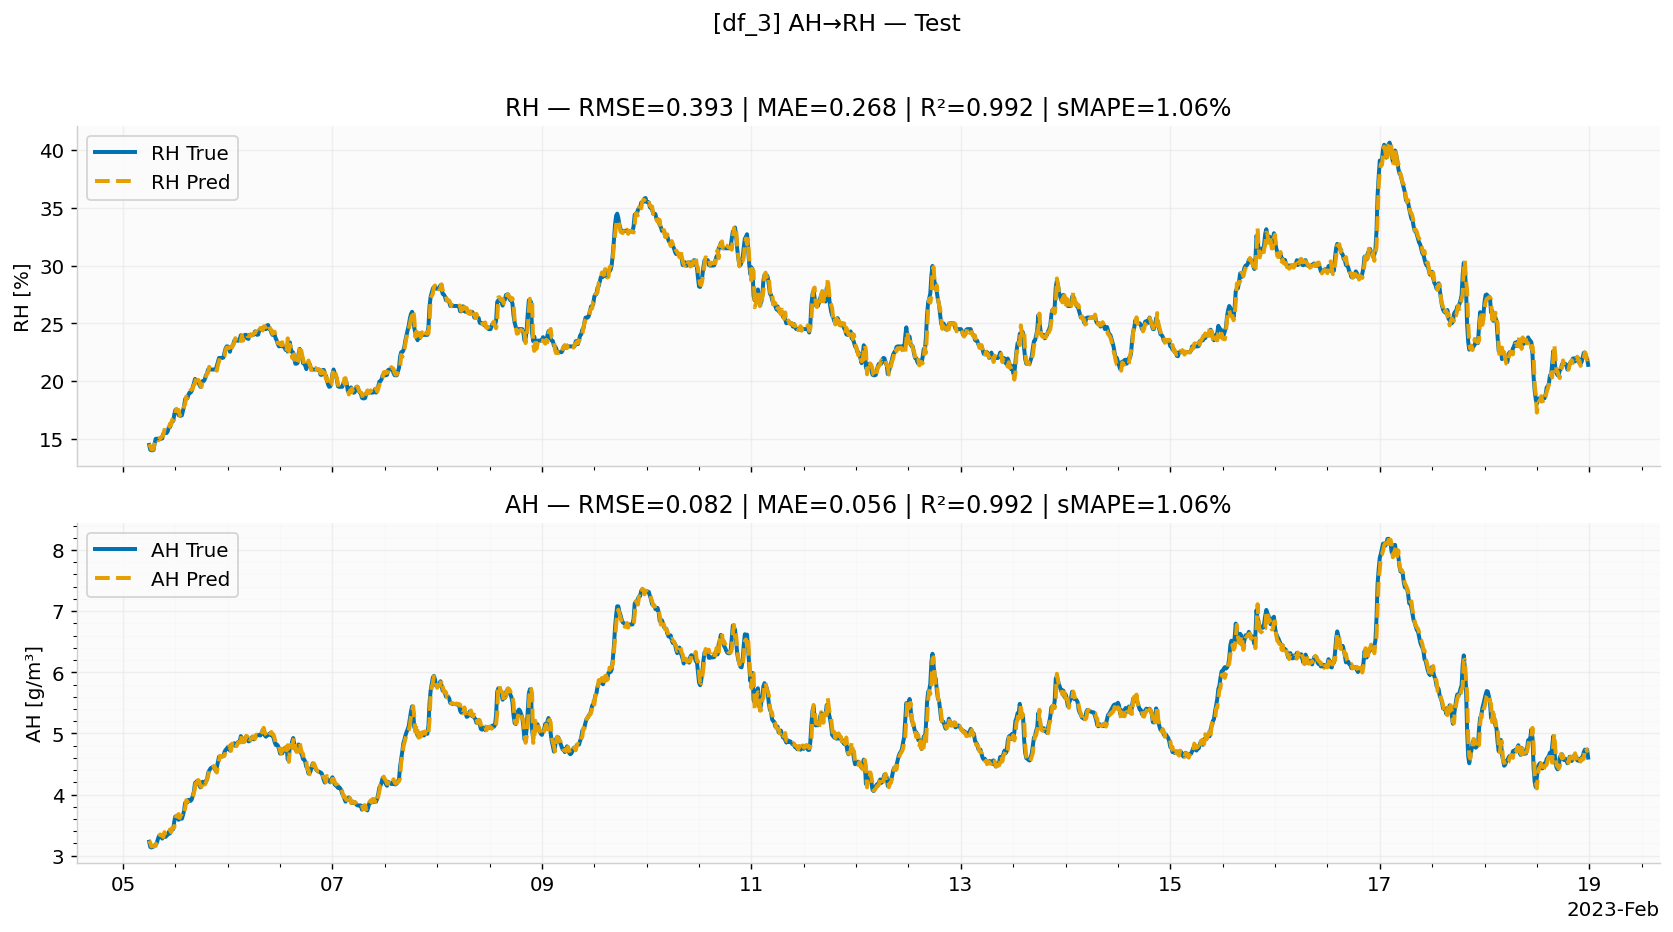

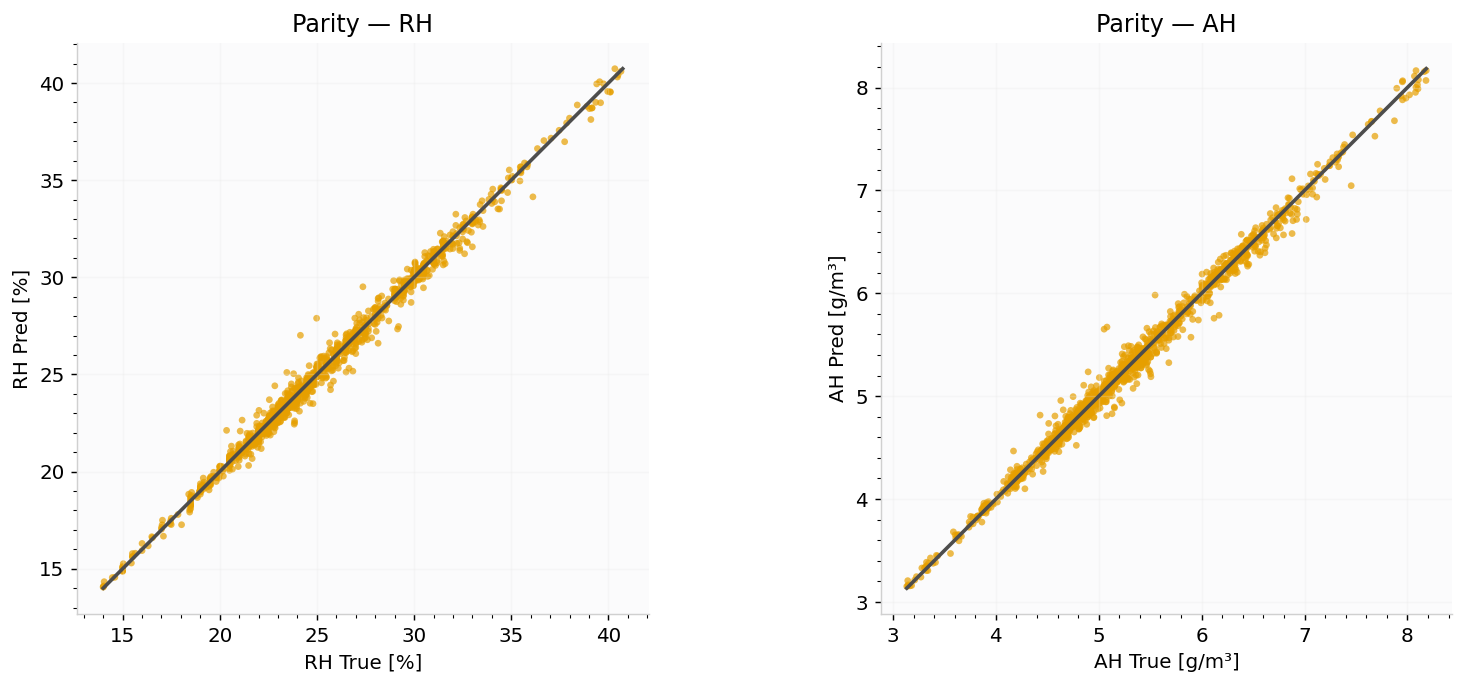

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_22752\678131728.py:258: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for b, sub in dfp.groupby(bins):
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_22752\4185999809.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["hvac_mode"] = df["hvac_mode"].fillna(0).astype(int)
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_22752\4185999809.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the d


==== Test by HVAC mode ====
 mode   RH_MAE  RH_RMSE   AH_MAE  AH_RMSE   N
    0 0.247378 0.367385 0.052249 0.077955 660
    1 0.244632 0.378646 0.050431 0.077694 340
    2 0.333565 0.453020 0.069927 0.095046 320

==== Test by hour ====
 hour   RH_MAE  RH_RMSE   AH_MAE  AH_RMSE  N
    0 0.299384 0.461058 0.061525 0.093965 52
    1 0.252037 0.349698 0.051908 0.071709 52
    2 0.246619 0.368562 0.050353 0.074657 52
    3 0.252731 0.336383 0.051900 0.069010 52
    4 0.178101 0.258128 0.036407 0.052864 52
    5 0.138384 0.178409 0.028286 0.036510 52
    6 0.166858 0.220382 0.034087 0.045067 56
    7 0.188366 0.245130 0.038357 0.049755 56
    8 0.157911 0.201542 0.032202 0.041018 56
    9 0.194137 0.236074 0.039999 0.048668 56
   10 0.223616 0.285959 0.047308 0.061198 56
   11 0.319305 0.466471 0.069841 0.102566 56
   12 0.289763 0.360714 0.065031 0.082738 56
   13 0.340410 0.467289 0.072972 0.099213 56
   14 0.287903 0.387874 0.062197 0.083512 56
   15 0.303363 0.387865 0.065182 0.084555 5

c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


✅ Saved best model → models/disaggregated\df_4\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_4\scaler_ah.pkl
Epoch 001 | RMSE (AH)=3.336 | val RMSE (AH)=0.706 | masked steps (train)=17544
✅ Saved best model → models/disaggregated\df_4\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_4\scaler_ah.pkl
Epoch 002 | RMSE (AH)=0.674 | val RMSE (AH)=0.253 | masked steps (train)=17544
✅ Saved best model → models/disaggregated\df_4\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_4\scaler_ah.pkl
Epoch 003 | RMSE (AH)=0.257 | val RMSE (AH)=0.165 | masked steps (train)=17544
Epoch 004 | RMSE (AH)=0.210 | val RMSE (AH)=0.168 | masked steps (train)=17544
✅ Saved best model → models/disaggregated\df_4\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_4\scaler_ah.pkl
Epoch 005 | RMSE (AH)=0.178 | val RMSE (AH)=0.092 | masked steps (train)=17544
Epoch 006 | RMSE (AH)=0.171 | val RMSE (AH)=0.113 | masked steps (train)=17544
Epoch 007 | RMSE (AH)=0.163 | val 

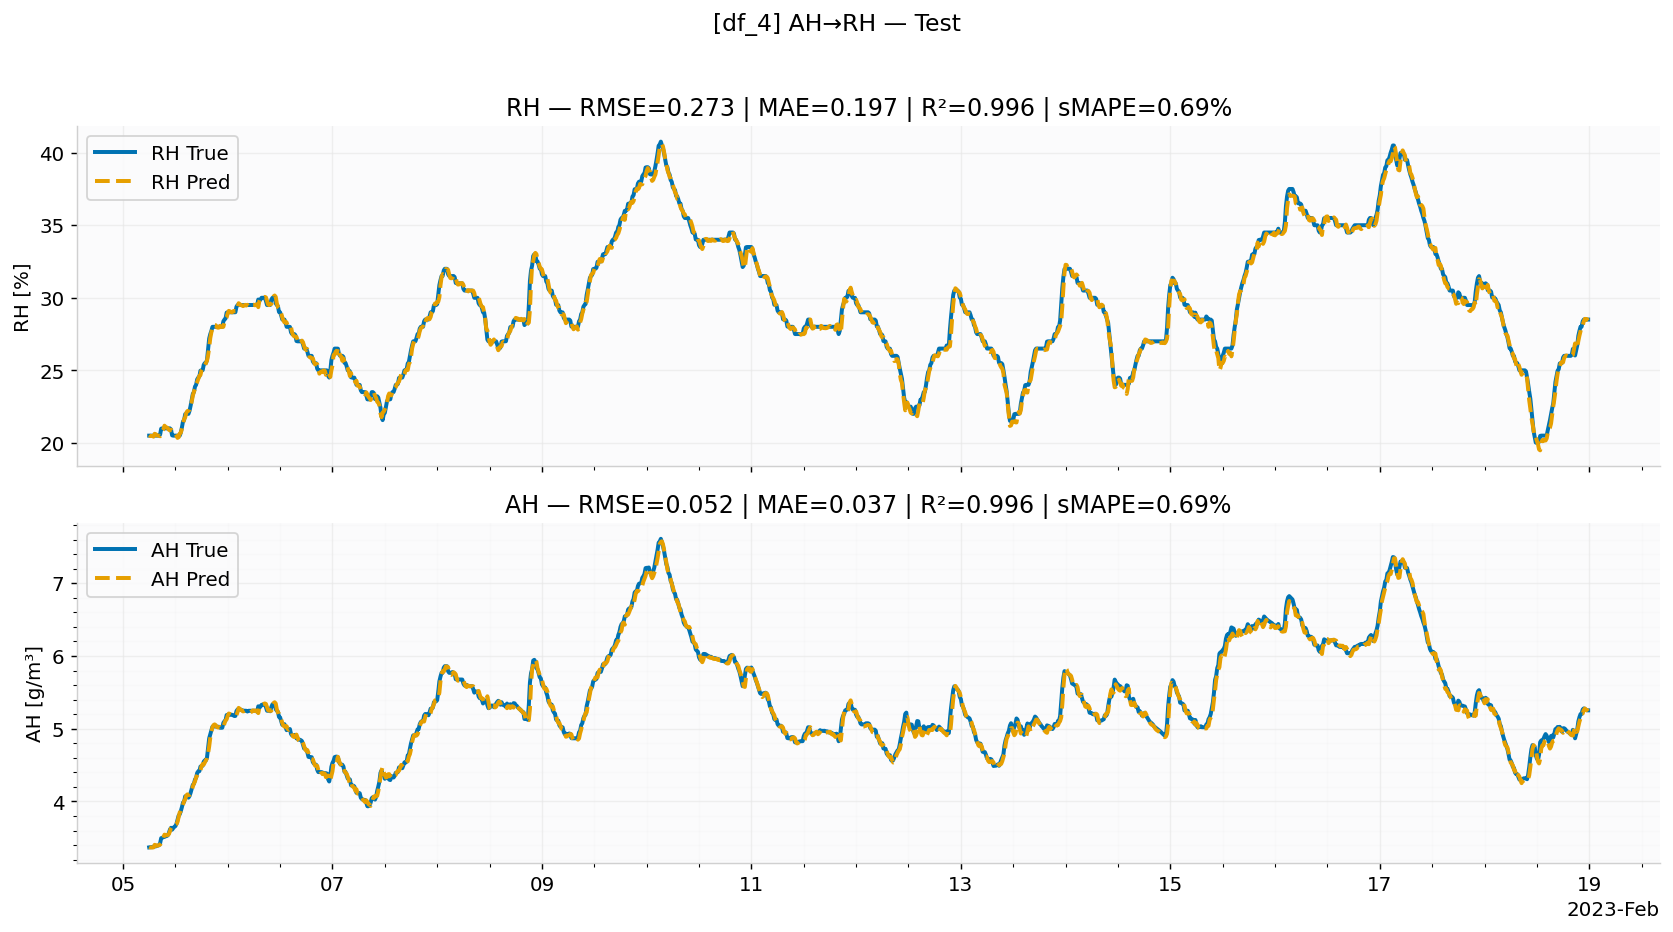

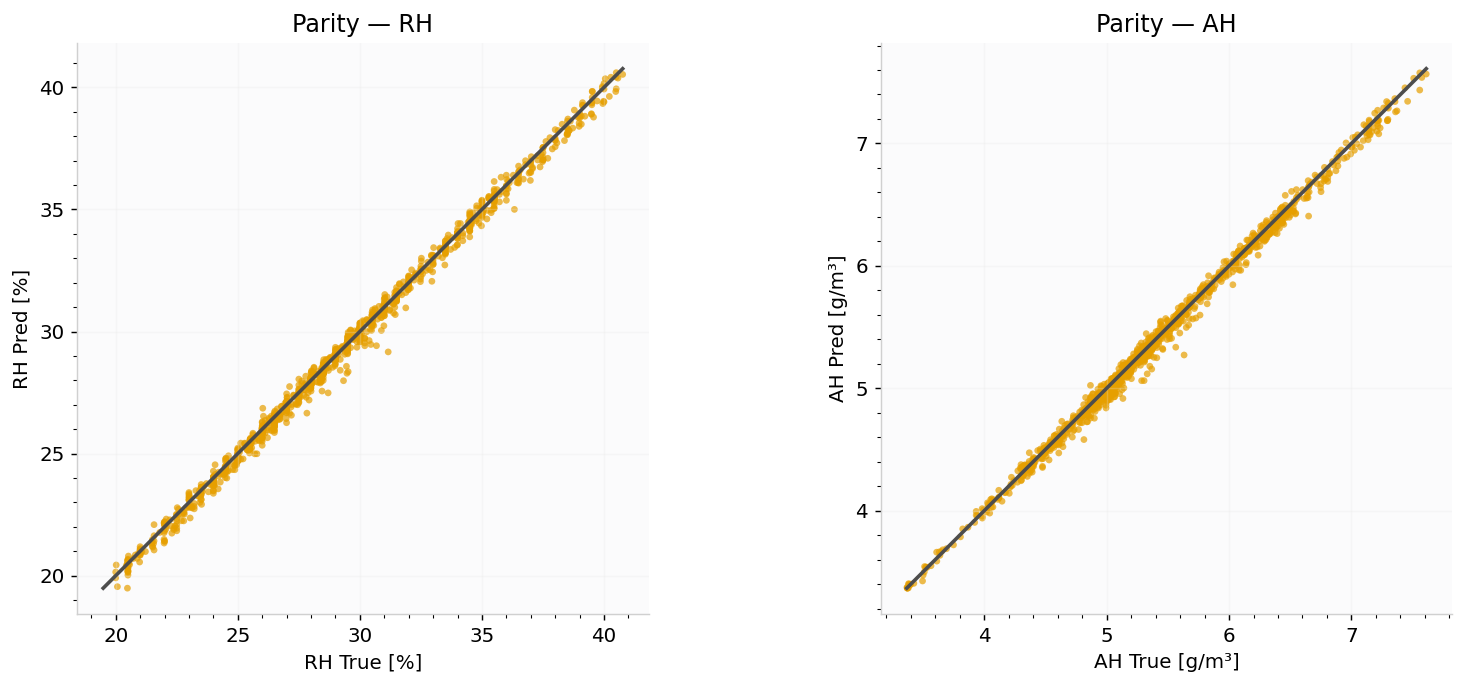

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_22752\678131728.py:258: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for b, sub in dfp.groupby(bins):
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_22752\4185999809.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["hvac_mode"] = df["hvac_mode"].fillna(0).astype(int)
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_22752\4185999809.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the d


==== Test by HVAC mode ====
 mode   RH_MAE  RH_RMSE   AH_MAE  AH_RMSE   N
    0 0.185192 0.258126 0.034596 0.048884 990
    1 0.208482 0.269038 0.039331 0.051706  95
    2 0.241528 0.331105 0.044872 0.061898 235

==== Test by hour ====
 hour   RH_MAE  RH_RMSE   AH_MAE  AH_RMSE  N
    0 0.218794 0.276376 0.039173 0.049517 52
    1 0.166639 0.216912 0.029946 0.039121 52
    2 0.252264 0.351029 0.045471 0.063956 52
    3 0.169051 0.223217 0.030240 0.040140 52
    4 0.178899 0.235867 0.031841 0.042291 52
    5 0.140693 0.178607 0.024789 0.031499 52
    6 0.126194 0.154131 0.022315 0.027349 56
    7 0.132852 0.175244 0.023302 0.030800 56
    8 0.154546 0.197966 0.027131 0.034740 56
    9 0.181353 0.224930 0.032542 0.040731 56
   10 0.275591 0.333793 0.052415 0.064295 56
   11 0.212358 0.278031 0.043809 0.058682 56
   12 0.233996 0.310118 0.048998 0.068115 56
   13 0.199097 0.242438 0.041019 0.051313 56
   14 0.186898 0.240466 0.038951 0.052429 56
   15 0.177830 0.237480 0.035702 0.049367 5

c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


✅ Saved best model → models/disaggregated\df_5\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_5\scaler_ah.pkl
Epoch 001 | RMSE (AH)=2.810 | val RMSE (AH)=0.468 | masked steps (train)=17544
✅ Saved best model → models/disaggregated\df_5\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_5\scaler_ah.pkl
Epoch 002 | RMSE (AH)=0.439 | val RMSE (AH)=0.236 | masked steps (train)=17544
✅ Saved best model → models/disaggregated\df_5\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_5\scaler_ah.pkl
Epoch 003 | RMSE (AH)=0.243 | val RMSE (AH)=0.155 | masked steps (train)=17544
✅ Saved best model → models/disaggregated\df_5\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_5\scaler_ah.pkl
Epoch 004 | RMSE (AH)=0.185 | val RMSE (AH)=0.152 | masked steps (train)=17544
✅ Saved best model → models/disaggregated\df_5\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_5\scaler_ah.pkl
Epoch 005 | RMSE (AH)=0.174 | val RMSE (AH)=0.138 | masked steps (tra

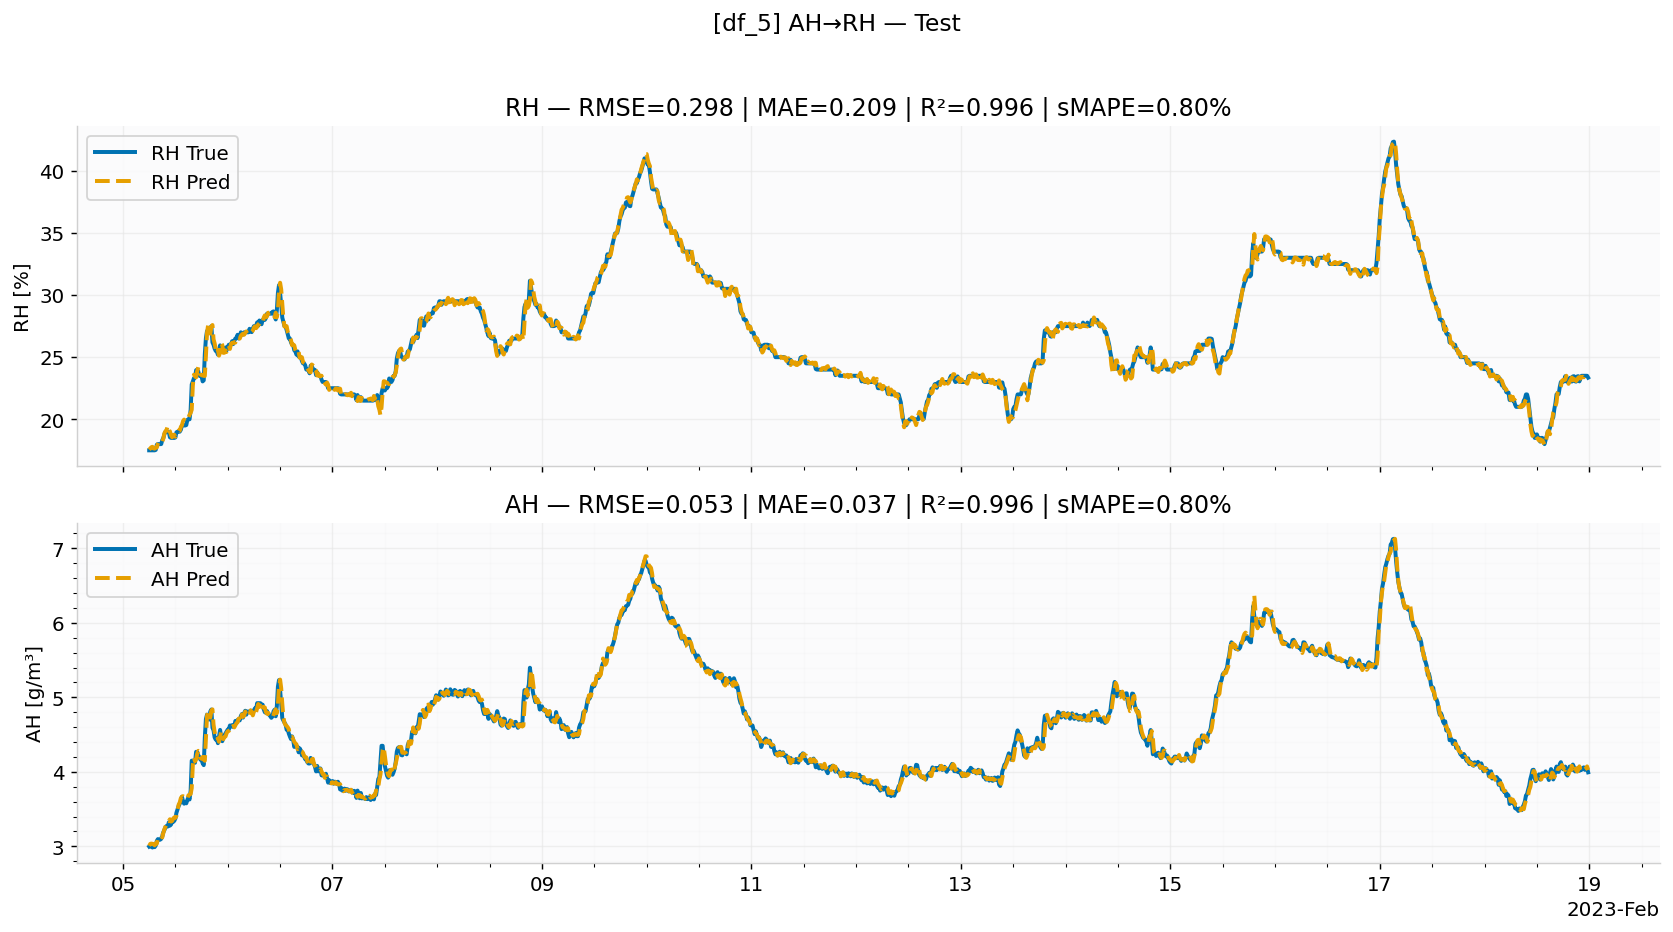

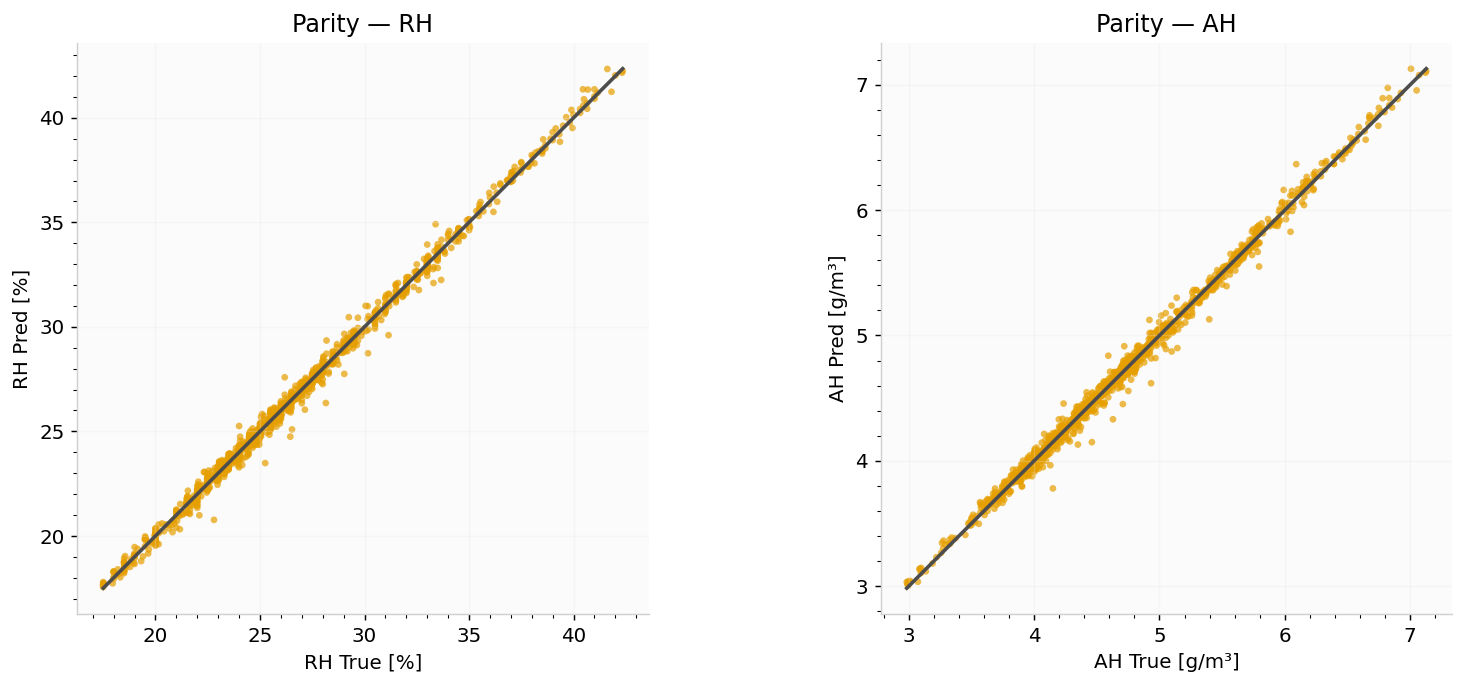

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_22752\678131728.py:258: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for b, sub in dfp.groupby(bins):
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_22752\4185999809.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["hvac_mode"] = df["hvac_mode"].fillna(0).astype(int)
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_22752\4185999809.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the d


==== Test by HVAC mode ====
 mode   RH_MAE  RH_RMSE   AH_MAE  AH_RMSE   N
    0 0.204698 0.288500 0.036373 0.051661 801
    1 0.211271 0.306408 0.037110 0.053972 231
    2 0.219900 0.317213 0.038023 0.055157 288

==== Test by hour ====
 hour   RH_MAE  RH_RMSE   AH_MAE  AH_RMSE  N
    0 0.155153 0.211116 0.026499 0.035872 52
    1 0.186505 0.227370 0.031814 0.038676 52
    2 0.130780 0.177705 0.022333 0.030263 52
    3 0.160756 0.239180 0.027365 0.040585 52
    4 0.152597 0.191363 0.025985 0.032525 52
    5 0.174859 0.224512 0.029743 0.038132 52
    6 0.186451 0.234419 0.031865 0.040125 56
    7 0.167327 0.214738 0.028534 0.036583 56
    8 0.178983 0.222509 0.030487 0.037881 56
    9 0.214647 0.261454 0.036823 0.044958 56
   10 0.258378 0.299092 0.046717 0.054715 56
   11 0.295525 0.398698 0.055563 0.074668 56
   12 0.263764 0.368614 0.048518 0.066370 56
   13 0.171821 0.222198 0.032575 0.042595 56
   14 0.179927 0.223474 0.033199 0.041111 56
   15 0.241835 0.392470 0.044815 0.073144 5

c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


✅ Saved best model → models/disaggregated\df_6\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_6\scaler_ah.pkl
Epoch 001 | RMSE (AH)=2.732 | val RMSE (AH)=0.310 | masked steps (train)=17544
✅ Saved best model → models/disaggregated\df_6\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_6\scaler_ah.pkl
Epoch 002 | RMSE (AH)=0.445 | val RMSE (AH)=0.236 | masked steps (train)=17544
✅ Saved best model → models/disaggregated\df_6\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_6\scaler_ah.pkl
Epoch 003 | RMSE (AH)=0.253 | val RMSE (AH)=0.167 | masked steps (train)=17544
✅ Saved best model → models/disaggregated\df_6\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_6\scaler_ah.pkl
Epoch 004 | RMSE (AH)=0.217 | val RMSE (AH)=0.154 | masked steps (train)=17544
Epoch 005 | RMSE (AH)=0.200 | val RMSE (AH)=0.158 | masked steps (train)=17544
✅ Saved best model → models/disaggregated\df_6\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_6\scal

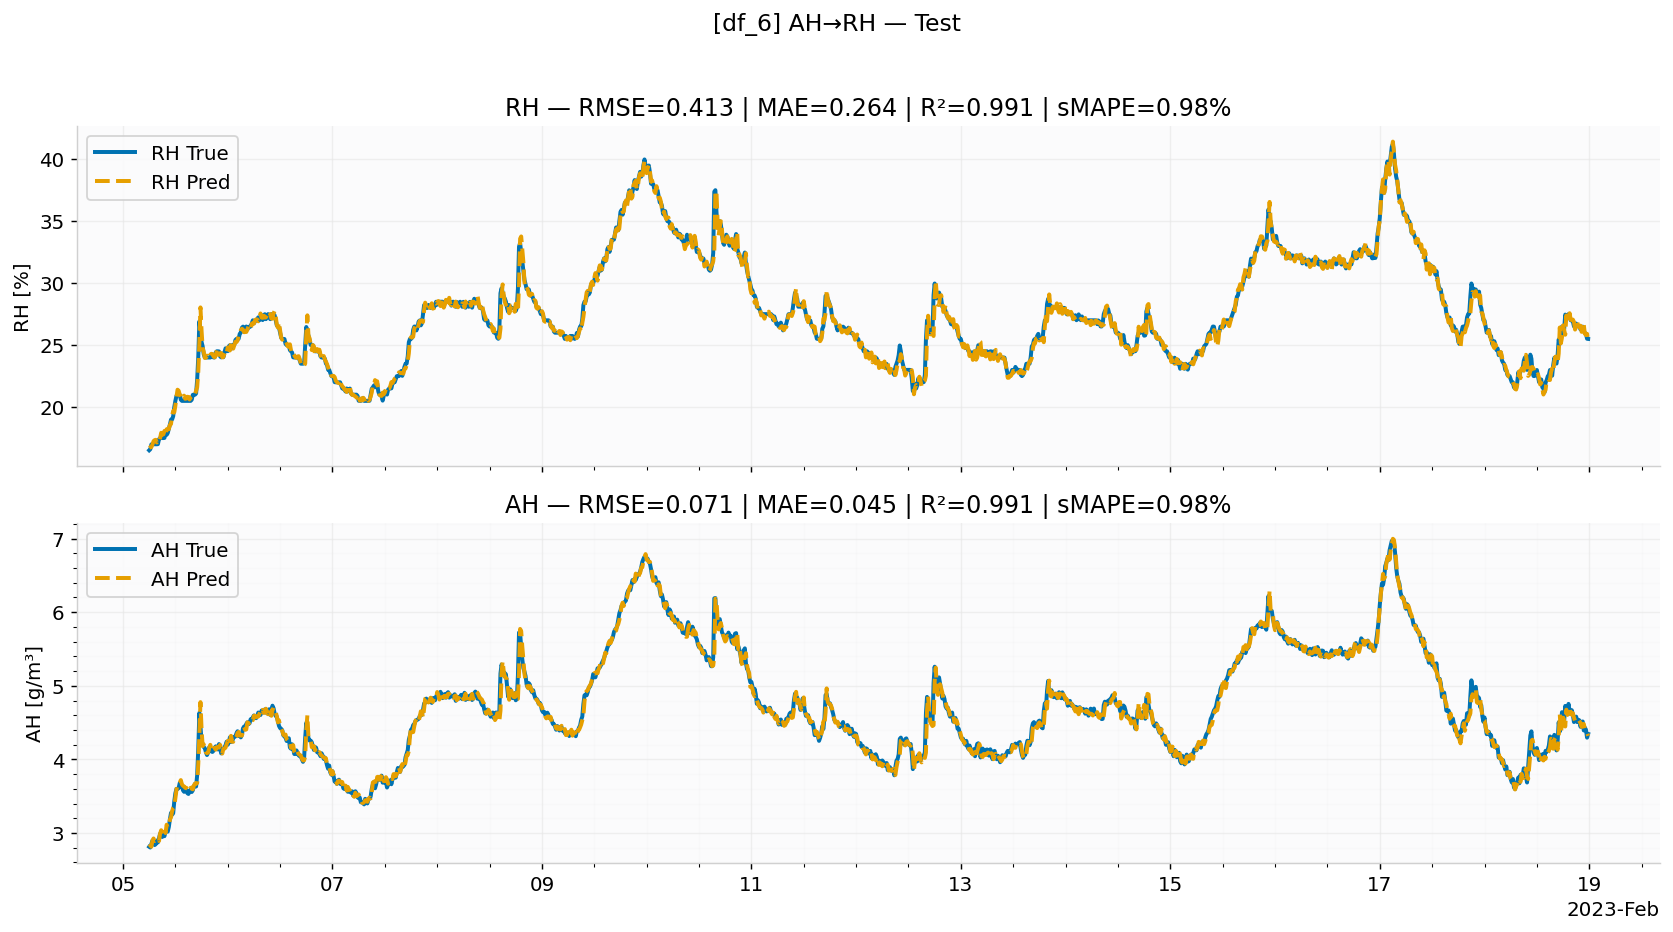

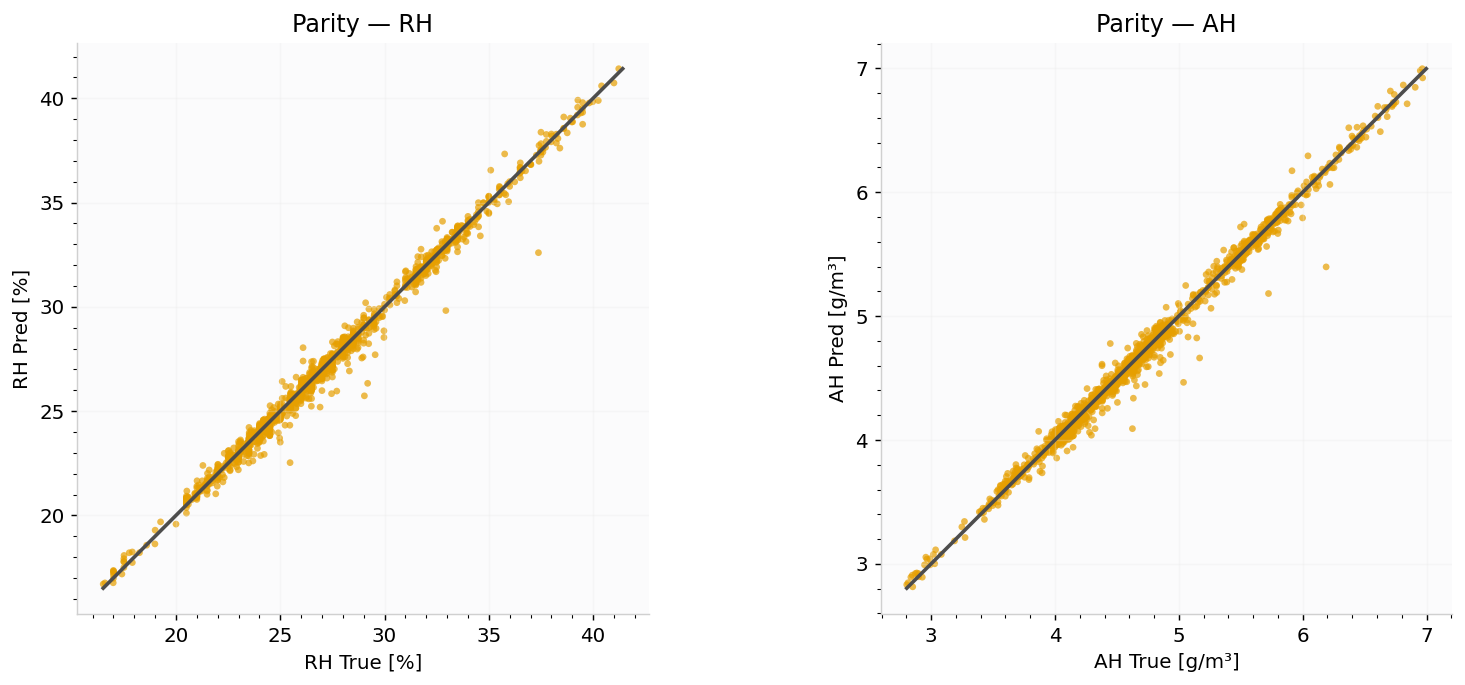

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_22752\678131728.py:258: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for b, sub in dfp.groupby(bins):
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_22752\4185999809.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["hvac_mode"] = df["hvac_mode"].fillna(0).astype(int)
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_22752\4185999809.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the d


==== Test by HVAC mode ====
 mode   RH_MAE  RH_RMSE   AH_MAE  AH_RMSE   N
    0 0.272164 0.441030 0.047115 0.076240 917
    1 0.212709 0.293002 0.036426 0.050283 175
    2 0.267737 0.375049 0.045595 0.063959 228

==== Test by hour ====
 hour   RH_MAE  RH_RMSE   AH_MAE  AH_RMSE  N
    0 0.206865 0.264072 0.035351 0.045124 52
    1 0.187312 0.240702 0.031990 0.041148 52
    2 0.211628 0.271679 0.036214 0.046545 52
    3 0.215814 0.268229 0.036711 0.045612 52
    4 0.186420 0.241642 0.031657 0.040853 52
    5 0.171727 0.223984 0.029254 0.038124 52
    6 0.177366 0.223878 0.030220 0.038149 56
    7 0.170335 0.212857 0.028875 0.035957 56
    8 0.200285 0.254968 0.033996 0.043302 56
    9 0.333403 0.404359 0.056365 0.068213 56
   10 0.321413 0.436945 0.055799 0.075963 56
   11 0.242860 0.305682 0.042913 0.054174 56
   12 0.232966 0.300211 0.041124 0.053241 56
   13 0.229996 0.314042 0.041080 0.056456 56
   14 0.255102 0.468510 0.044927 0.082861 56
   15 0.317159 0.707289 0.055290 0.118837 5

c:\Users\Kelsier\.conda\envs\thesis\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


✅ Saved best model → models/disaggregated\df_7\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_7\scaler_ah.pkl
Epoch 001 | RMSE (AH)=2.776 | val RMSE (AH)=0.400 | masked steps (train)=17544
✅ Saved best model → models/disaggregated\df_7\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_7\scaler_ah.pkl
Epoch 002 | RMSE (AH)=0.516 | val RMSE (AH)=0.201 | masked steps (train)=17544
Epoch 003 | RMSE (AH)=0.244 | val RMSE (AH)=0.216 | masked steps (train)=17544
✅ Saved best model → models/disaggregated\df_7\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_7\scaler_ah.pkl
Epoch 004 | RMSE (AH)=0.219 | val RMSE (AH)=0.197 | masked steps (train)=17544
✅ Saved best model → models/disaggregated\df_7\best_ah.pt
🧪 Saved scaler → models/disaggregated\scalers\df_7\scaler_ah.pkl
Epoch 005 | RMSE (AH)=0.183 | val RMSE (AH)=0.176 | masked steps (train)=17544
Epoch 006 | RMSE (AH)=0.181 | val RMSE (AH)=0.177 | masked steps (train)=17544
✅ Saved best model → models/disagg

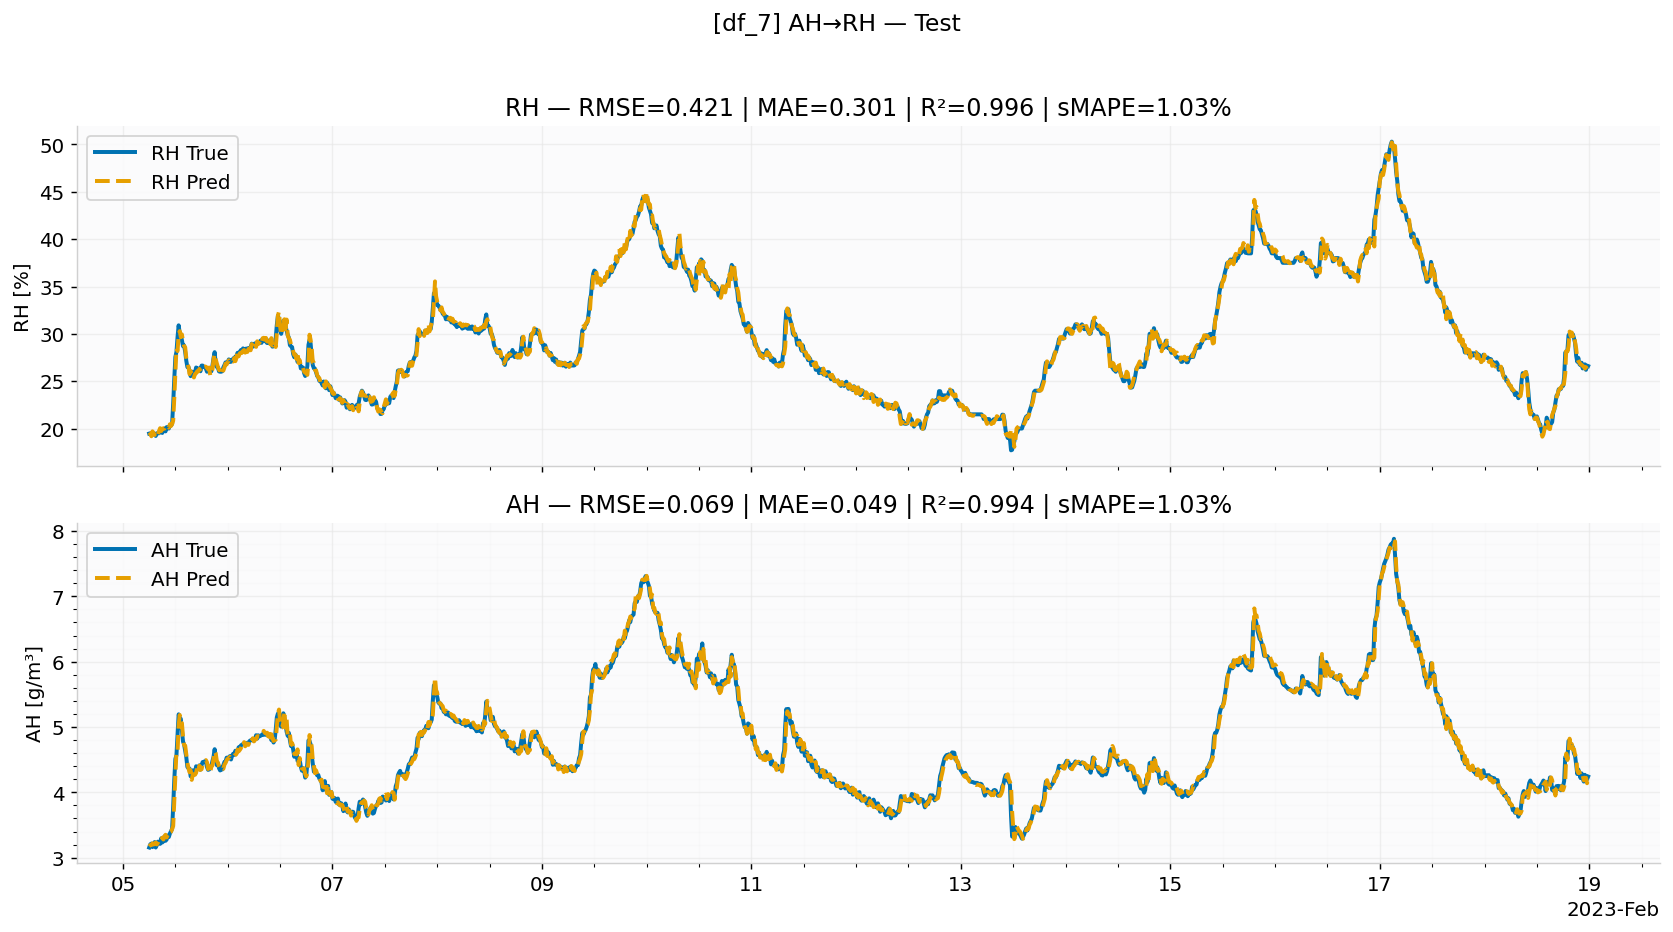

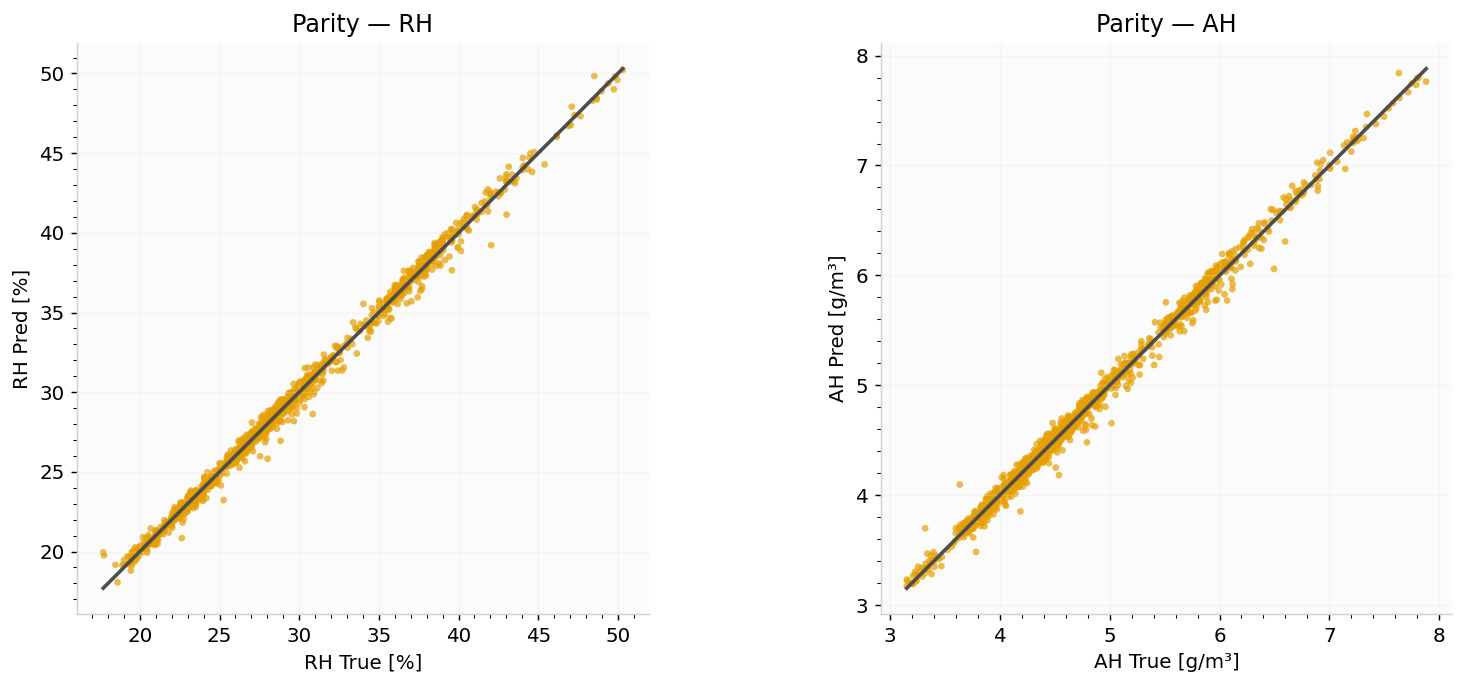


==== Test by HVAC mode ====
 mode   RH_MAE  RH_RMSE   AH_MAE  AH_RMSE   N
    0 0.299118 0.419150 0.049031 0.069101 781
    1 0.304936 0.429110 0.049253 0.069094 194
    2 0.303434 0.421201 0.048851 0.067892 345

==== Test by hour ====
 hour   RH_MAE  RH_RMSE   AH_MAE  AH_RMSE  N
    0 0.235976 0.301712 0.037630 0.048088 52
    1 0.243078 0.301392 0.038681 0.047653 52
    2 0.196100 0.235701 0.031439 0.037671 52
    3 0.219485 0.323716 0.035528 0.051942 52
    4 0.169297 0.230161 0.027231 0.036910 52
    5 0.193244 0.236414 0.031183 0.038287 52
    6 0.220761 0.308955 0.034964 0.048571 56
    7 0.311079 0.456020 0.049933 0.073658 56
    8 0.268569 0.354768 0.042879 0.056531 56
    9 0.281679 0.352201 0.045239 0.056525 56
   10 0.362446 0.508765 0.060540 0.083198 56
   11 0.577308 0.787420 0.097408 0.136276 56
   12 0.407801 0.540079 0.068166 0.089904 56
   13 0.289051 0.376437 0.048521 0.062739 56
   14 0.283903 0.334811 0.047967 0.056910 56
   15 0.302652 0.378746 0.050627 0.063253 5

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_22752\678131728.py:258: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for b, sub in dfp.groupby(bins):


In [27]:
run_ah_for_folder('datasets/retrofit/resampled/disaggregated', hvac_col="hvac_mode", save_root="models/disaggregated", win_ah=24)